In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4, 3]

import MDAnalysis
from MDAnalysis.analysis import *
import mdtraj as mdt
import pandas as pd
from scipy.optimize import minimize
from scipy import stats
from scipy.ndimage import uniform_filter1d

from sklearn.decomposition import PCA
from bussilab import clustering

import plumed as plu

import copy
import os
import pickle
from time import time
import datetime

import itertools

from pyvis import network as net
from pyvis import options as opt
import networkx as nx

In [653]:
plt.style.use('tableau-colorblind10')
#plt.style.use('default')

In [654]:
path='./input/'
path_out='./output_check/'
exp_whole=np.loadtxt(path+'SASDQT9_RAD51-BRC4.dat')

In [655]:
# Guinnier experimental for Rg
slope, intercept, r_value, p_value, std_err = stats.linregress(
    exp_whole[48:310,0]**2,
    np.log(exp_whole[48:310,1]))
print('Guinier fit Rg:',np.sqrt(-3*slope))

Guinier fit Rg: 28.600869618541115


In [656]:
shift=48
selected_points=np.argmin((np.linspace(0.01,0.27,27).reshape(-1,1)-exp_whole[48:2056,0])**2,axis=1)+shift

In [657]:
uf_exp_whole=uniform_filter1d(exp_whole[:,1], size=51,mode='reflect')
uf_exp_whole.shape

(2569,)

In [658]:
print("SCALE_EXPINT="+str(np.exp(intercept)))
for i in range(len(selected_points)):
    print("QVALUE"+str(int(i+1))+'='+str(exp_whole[selected_points[i],0])+' '+"EXPINT"+str(int(i+1))+"="+str(uf_exp_whole[selected_points[i]]))

SCALE_EXPINT=0.03308254964675395
QVALUE1=0.01077103 EXPINT1=0.032496143921568625
QVALUE2=0.02004692 EXPINT2=0.029574363529411757
QVALUE3=0.02997605 EXPINT3=0.02573280137254901
QVALUE4=0.04003583 EXPINT4=0.021387183333333313
QVALUE5=0.04996495 EXPINT5=0.017315874509803902
QVALUE6=0.06002473 EXPINT6=0.013607859411764688
QVALUE7=0.06995385 EXPINT7=0.010560911352941158
QVALUE8=0.08001363 EXPINT8=0.007967748960784298
QVALUE9=0.08994276 EXPINT9=0.006012438235294102
QVALUE10=0.1000025 EXPINT10=0.004477551431372533
QVALUE11=0.1100623 EXPINT11=0.003312513862745081
QVALUE12=0.1199914 EXPINT12=0.00240160503921567
QVALUE13=0.1300512 EXPINT13=0.0017190352549019455
QVALUE14=0.1399803 EXPINT14=0.0011963419411764554
QVALUE15=0.1500401 EXPINT15=0.0008124202607842982
QVALUE16=0.1599692 EXPINT16=0.0006005266058823376
QVALUE17=0.170029 EXPINT17=0.0004546479431372395
QVALUE18=0.1799581 EXPINT18=0.0003499681941176316
QVALUE19=0.1900179 EXPINT19=0.00030712468627449425
QVALUE20=0.199947 EXPINT20=0.00024375893

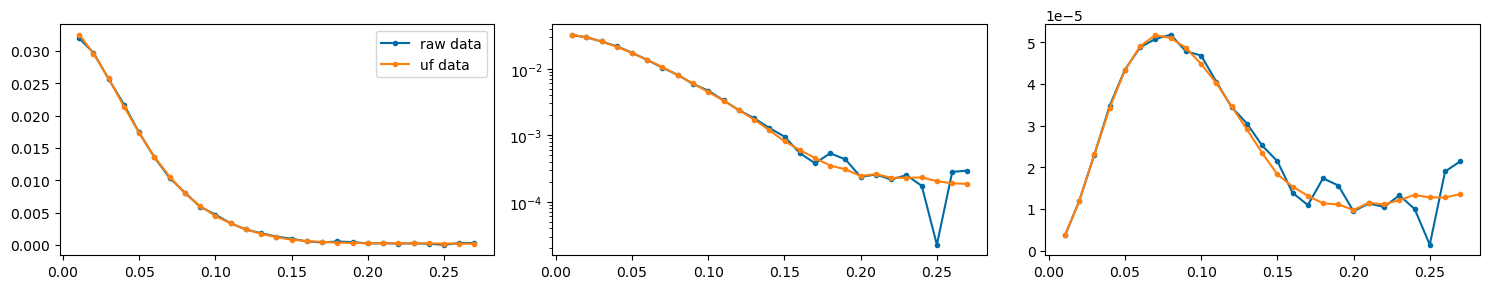

In [659]:
plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
plt.plot(exp_whole[selected_points,0],exp_whole[selected_points,1],'.-',label='raw data')
plt.plot(exp_whole[selected_points,0],uf_exp_whole[selected_points],'.-',label='uf data')
plt.legend()
plt.subplot(1,3,2)
plt.plot(exp_whole[selected_points,0],exp_whole[selected_points,1],'.-',label='raw data')
plt.plot(exp_whole[selected_points,0],uf_exp_whole[selected_points],'.-',label='uf data')
plt.yscale('log')
plt.subplot(1,3,3)
plt.plot(exp_whole[selected_points,0],exp_whole[selected_points,1]*exp_whole[selected_points,0]**2,'.-',label='raw data')
plt.plot(exp_whole[selected_points,0],uf_exp_whole[selected_points]*exp_whole[selected_points,0]**2,'.-',label='uf data')
plt.tight_layout()
plt.show()

## SteeredMD:

In [660]:
exp_spectrum=np.loadtxt(path+'SASDQT9_RAD51-BRC4.dat',comments=['#','@'])

In [661]:
colv_m1=plu.read_as_pandas(path+'colvar_steered_m_1')
colv_m2=plu.read_as_pandas(path+'colvar_steered_m_2')
colv_m3=plu.read_as_pandas(path+'colvar_steered_m_3')

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/mbernetti/my_progs/miniconda3/lib/libplumedKernel.dylib" +++
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1123373399.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colv_m1=plu.read_as_pandas(path+'colvar_steered_m_1')
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/mbernetti/my_progs/miniconda3/lib/libplumedKernel.dylib" +++
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1123373399.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colv_m2=plu.read_as_pandas(path+'colvar_steered_m_2')
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/mbernetti/my_progs/miniconda3/lib/libplumedKernel.dylib" +++
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipyk

In [662]:
colv_m1_np=np.loadtxt(path+'colvar_steered_m_1',skiprows=1)
colv_m2_np=np.loadtxt(path+'colvar_steered_m_2',skiprows=1)
colv_m3_np=np.loadtxt(path+'colvar_steered_m_3',skiprows=1)

In [663]:
qs_mart_file="""QVALUE1=0.0101178 EXPINT1=0.03268278549019608
QVALUE2=0.02004692 EXPINT2=0.029574363529411757
QVALUE3=0.02997605 EXPINT3=0.02573280137254901
QVALUE4=0.03990518 EXPINT4=0.021441139215686255
QVALUE5=0.04996495 EXPINT5=0.017315874509803902
QVALUE6=0.06002473 EXPINT6=0.013607859411764688
QVALUE7=0.06995385 EXPINT7=0.010560911352941158
QVALUE8=0.08001363 EXPINT8=0.007967748960784298
QVALUE9=0.08994276 EXPINT9=0.006012438235294102
QVALUE10=0.1000025 EXPINT10=0.004477551431372533
QVALUE11=0.1199914 EXPINT11=0.00240160503921567
QVALUE12=0.1399803 EXPINT12=0.0011963419411764554
QVALUE13=0.1599692 EXPINT13=0.0006005266058823376
QVALUE14=0.1799581 EXPINT14=0.0003499681941176316
QVALUE15=0.199947 EXPINT15=0.00024375893686272957
QVALUE16=0.2200666 EXPINT16=0.00023157075156861204
QVALUE17=0.2400555 EXPINT17=0.0002318339798039062
QVALUE18=0.2600444 EXPINT18=0.00018894343299998486
QVALUE19=0.2800333 EXPINT19=0.00017391225274508286
"""

In [664]:
qs_mart=np.array([a.split(sep='=') for a in np.array(qs_mart_file.split())[::2]])[:,1].astype(float)

In [665]:
exp_saxs=np.array([a.split(sep='=') for a in np.array(qs_mart_file.split())[1::2]])[:,1].astype(float)

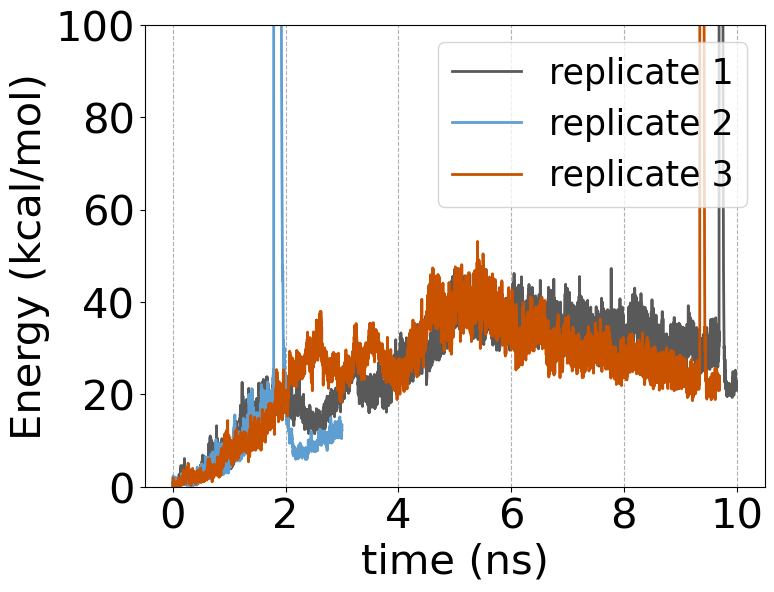

In [666]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ylim(0,100)
plt.ylabel('Energy (kcal/mol)',fontsize=30)
plt.xlabel('time (ns)',fontsize=30)
plt.xticks(fontsize=30)
#plt.tick_params(labelbottom = False, bottom = False) 
plt.yticks(np.arange(0,120,20),fontsize=30)
plt.grid(axis='x',ls='--')
plt.plot(colv_m1['time']/1000,colv_m1['steered.bias']/4.184,label='replicate 1',lw=2,color='C3')
plt.plot(colv_m2['time'][0:3000]/1000,colv_m2['steered.bias'][0:3000]/4.184,label='replicate 2',lw=2,color='C4')
plt.plot(colv_m3['time'][0:9700]/1000,colv_m3['steered.bias'][0:9700]/4.184,label='replicate 3',lw=2,color='C5')
plt.legend(fontsize=25,loc='upper right')
plt.show()
#plt.savefig(path_out+'bias_martini_nox_energy.svg',dpi=300,bbox_inches='tight')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1867604339.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=30)


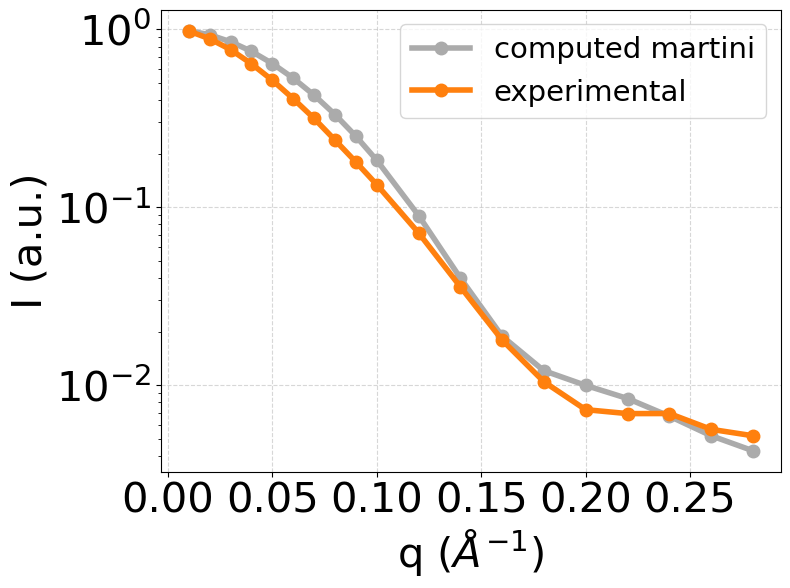

In [667]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.grid(ls='--',alpha=0.5)
plt.ylabel('I (a.u.)',fontsize=30)
plt.xlabel('q ($\AA^{-1}$)',fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
#plt.tick_params(labelbottom = False, bottom = False) 
plt.plot(qs_mart,colv_m1_np[0,1:20],'.-',label='computed martini',ms=18,lw=4,color='C2')
plt.plot(qs_mart,(exp_saxs/0.033474980320492204),'.-',label='experimental',ms=18,lw=4,color='C1')
plt.yscale('log')
plt.legend(fontsize=21,loc='upper right')
plt.show()
#plt.savefig(path_out+'log_martini_nox.svg',dpi=300,bbox_inches='tight')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/98984131.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/98984131.py:6: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=30)


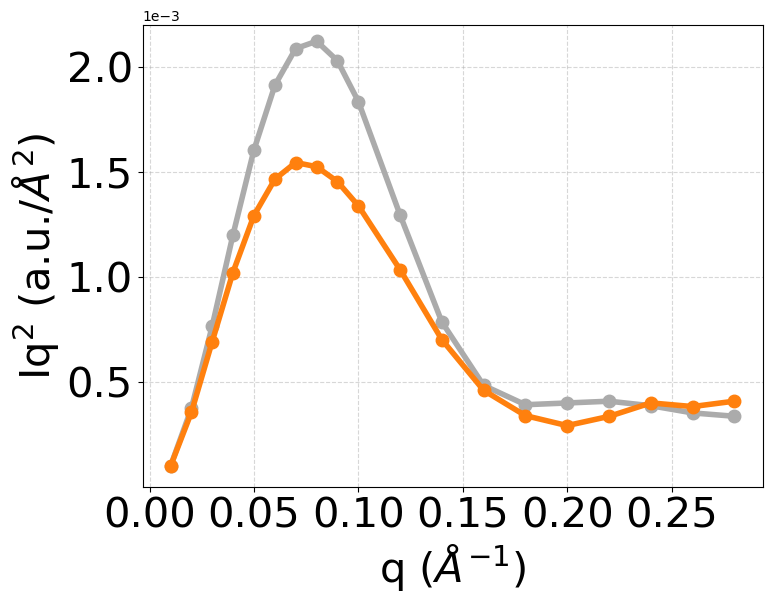

In [668]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.grid(ls='--',alpha=0.5)
plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
plt.xlabel('q ($\AA^{-1}$)',fontsize=30)
plt.xticks(fontsize=30)
#plt.tick_params(labelbottom = False, bottom = False) 
plt.yticks(np.arange(0.0005, 0.0025, step=0.0005),fontsize=30)
plt.ylim(0,0.0022)
plt.plot(qs_mart,colv_m1_np[0,1:20]*qs_mart**2,'.-',label='computed martini',ms=18,lw=4,color='C2')
plt.plot(qs_mart,(exp_saxs/0.033474980320492204)*qs_mart**2,'.-',label='experimental',ms=18,lw=4,color='C1')
plt.show()
#plt.savefig(path_out+'kratky_martini_nox.svg',dpi=300,bbox_inches='tight')

In [669]:
colv_b1=plu.read_as_pandas(path+'colvar_steered_106_10ns_onebead_1')
colv_b2=plu.read_as_pandas(path+'colvar_steered_106_10ns_onebead_2')
colv_b3=plu.read_as_pandas(path+'colvar_steered_106_10ns_onebead_3')

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/mbernetti/my_progs/miniconda3/lib/libplumedKernel.dylib" +++
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/4001729819.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colv_b1=plu.read_as_pandas(path+'colvar_steered_106_10ns_onebead_1')
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/mbernetti/my_progs/miniconda3/lib/libplumedKernel.dylib" +++
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/4001729819.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colv_b2=plu.read_as_pandas(path+'colvar_steered_106_10ns_onebead_2')
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/mbernetti/my_progs/miniconda3/lib/libplumedKernel.dylib" +++
/var/folders/6x/hzxn2pp

In [670]:
colv_b1_np=np.loadtxt(path+'colvar_steered_106_10ns_onebead_1',skiprows=1)
colv_b2_np=np.loadtxt(path+'colvar_steered_106_10ns_onebead_2',skiprows=1)
colv_b3_np=np.loadtxt(path+'colvar_steered_106_10ns_onebead_3',skiprows=1)

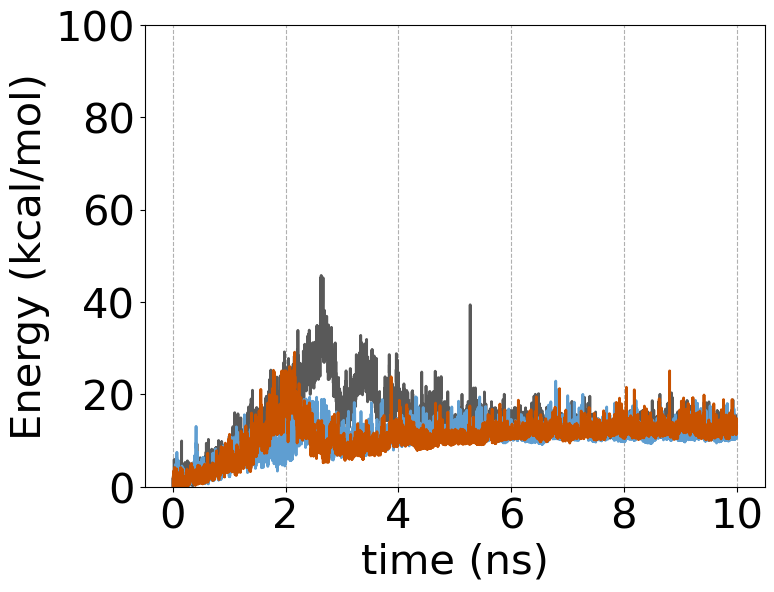

In [671]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ylim(0,100)
plt.ylabel('Energy (kcal/mol)',fontsize=30)
plt.xlabel('time (ns)',fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(np.arange(0,120,20),fontsize=30)
plt.grid(axis='x',ls='--')
plt.plot(colv_b1['time']/1000,colv_b1['steered.bias']/4.184,lw=2,color='C3') #replicate1
plt.plot(colv_b2['time']/1000,colv_b2['steered.bias']/4.184,lw=2,color='C4') #replicate2
plt.plot(colv_b3['time']/1000,colv_b3['steered.bias']/4.184,lw=2,color='C5') #replicate3
plt.show()
#plt.savefig(path_out+'bias_1b_energy.svg',dpi=300,bbox_inches='tight')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1058821442.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=30)


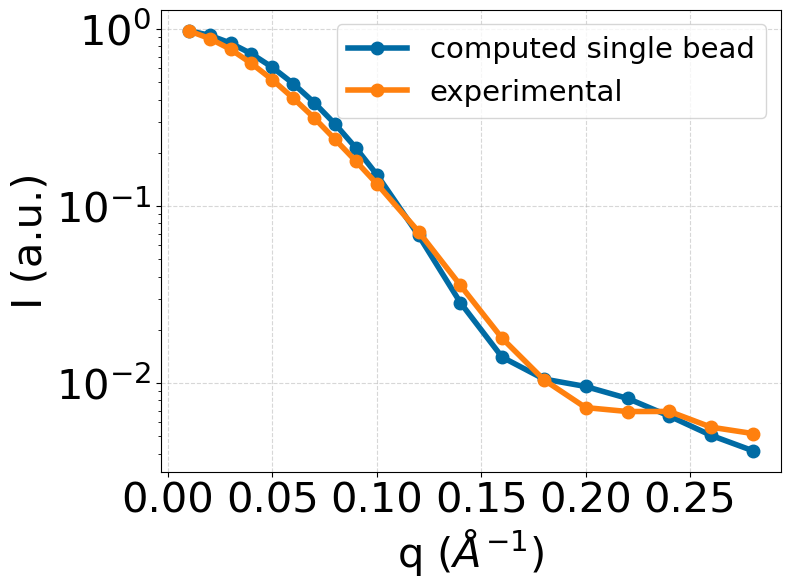

In [672]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.grid(ls='--',alpha=0.5)
plt.ylabel('I (a.u.)',fontsize=30)
plt.xlabel('q ($\AA^{-1}$)',fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.plot(qs_mart,colv_b1_np[0,1:20],'.-',label='computed single bead',ms=18,lw=4)
plt.plot(qs_mart,(exp_saxs/0.033474980320492204),'.-',label='experimental',ms=18,lw=4)
plt.yscale('log')
plt.legend(fontsize=21,loc='upper right')
plt.show()
#plt.savefig(path_out+'log_1b.svg',dpi=300,bbox_inches='tight')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3199065921.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3199065921.py:6: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=30)


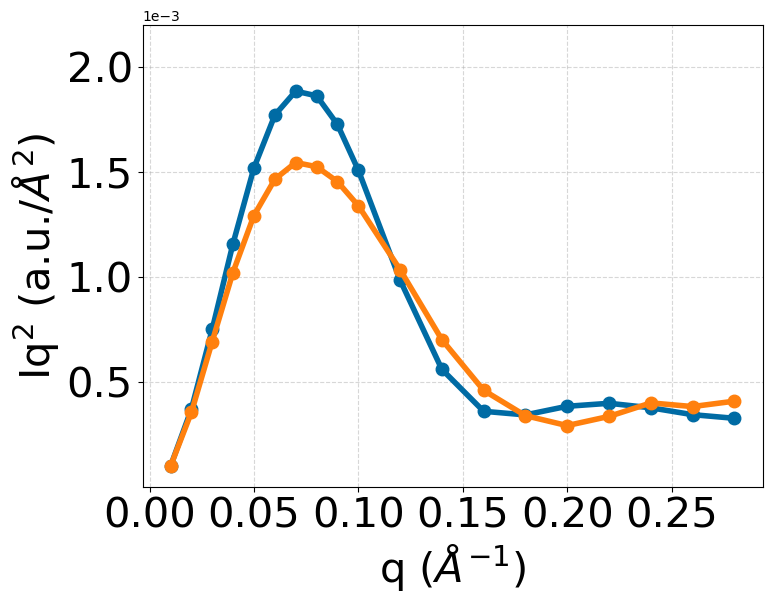

In [673]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.grid(ls='--',alpha=0.5)
plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
plt.xlabel('q ($\AA^{-1}$)',fontsize=30)
plt.xticks(fontsize=30)
plt.ylim(0,0.0022) 
plt.yticks(np.arange(0.0005, 0.0025, step=0.0005),fontsize=30)
plt.plot(qs_mart,colv_b1_np[0,1:20]*qs_mart**2,'.-',label='computed single bead',ms=18,lw=4)
plt.plot(qs_mart,(exp_saxs/0.033474980320492204)*qs_mart**2,'.-',label='experimental',ms=18,lw=4)
plt.show()
#plt.savefig(path_out+'kratky_1b.svg',dpi=300,bbox_inches='tight')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/129052633.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/129052633.py:6: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=30)


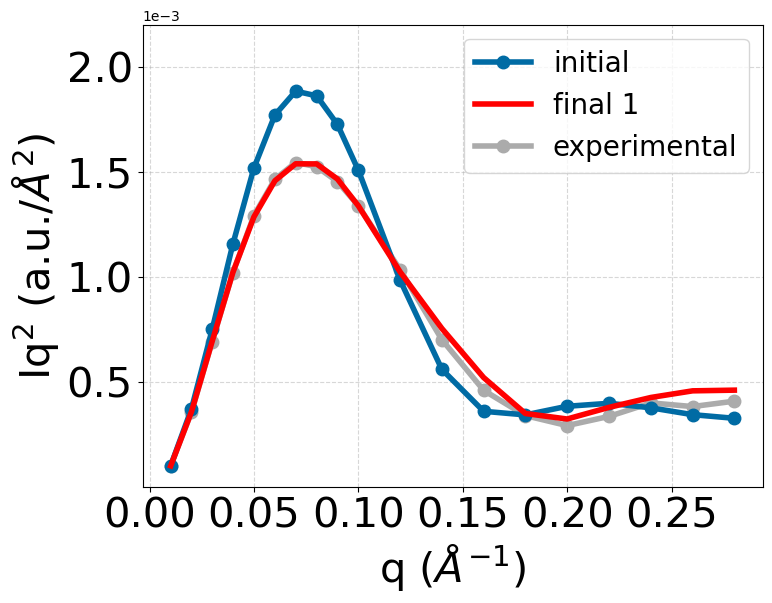

In [674]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.grid(ls='--',alpha=0.5)
plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
plt.xlabel('q ($\AA^{-1}$)',fontsize=30)
plt.xticks(fontsize=30)
plt.ylim(0,0.0022) 
plt.yticks(np.arange(0.0005, 0.0025, step=0.0005),fontsize=30)
plt.plot(qs_mart,colv_b1_np[0,1:20]*qs_mart**2,'.-',label='initial',ms=18,lw=4)
plt.plot(qs_mart,colv_b1_np[-1,1:20]*qs_mart**2,label='final 1',ms=18,lw=4,color='red')
plt.plot(qs_mart,(exp_saxs/0.033474980320492204)*qs_mart**2,'.-',label='experimental',ms=18,lw=4,zorder=0,color='C2')
plt.legend(fontsize=20)
plt.show()
#plt.savefig(path_out+'kratky_1b_final_st1.svg',dpi=300,bbox_inches='tight')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/466216445.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/466216445.py:6: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=30)


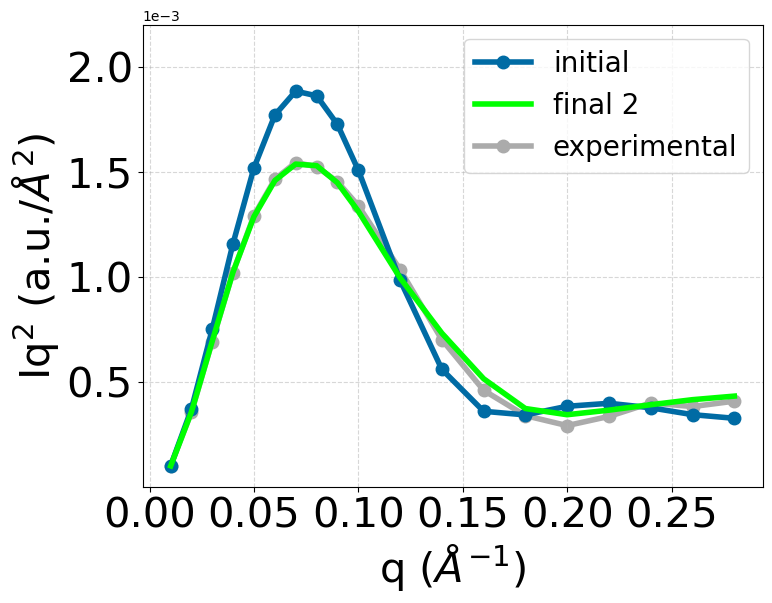

In [675]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.grid(ls='--',alpha=0.5)
plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
plt.xlabel('q ($\AA^{-1}$)',fontsize=30)
plt.xticks(fontsize=30)
plt.ylim(0,0.0022) 
plt.yticks(np.arange(0.0005, 0.0025, step=0.0005),fontsize=30)
plt.plot(qs_mart,colv_b1_np[0,1:20]*qs_mart**2,'.-',label='initial',ms=18,lw=4)
plt.plot(qs_mart,colv_b2_np[-1,1:20]*qs_mart**2,label='final 2',ms=18,lw=4,color='lime')
plt.plot(qs_mart,(exp_saxs/0.033474980320492204)*qs_mart**2,'.-',label='experimental',ms=18,lw=4,zorder=0,color='C2')
plt.legend(fontsize=20)
plt.show()
#plt.savefig(path_out+'kratky_1b_final_st2.svg',dpi=300,bbox_inches='tight')

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1741270068.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1741270068.py:6: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=30)


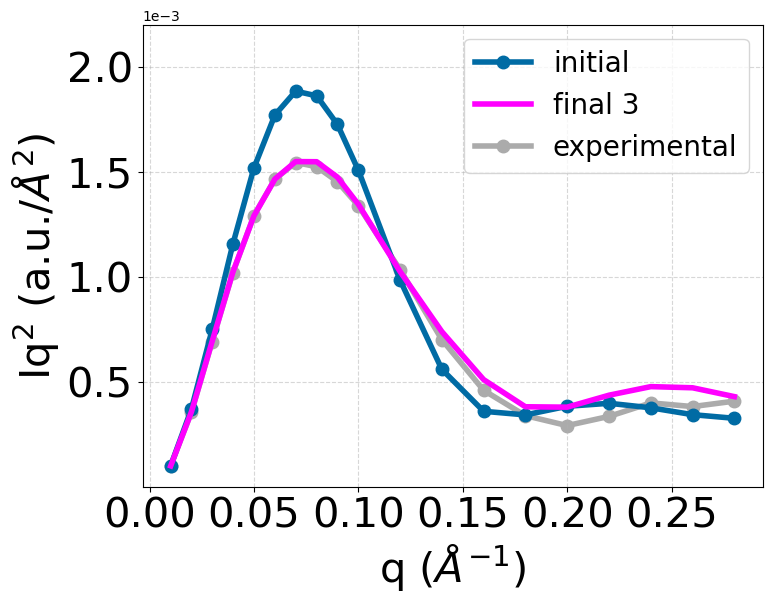

In [676]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.grid(ls='--',alpha=0.5)
plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=30)
plt.xlabel('q ($\AA^{-1}$)',fontsize=30)
plt.xticks(fontsize=30)
plt.ylim(0,0.0022) 
plt.yticks(np.arange(0.0005, 0.0025, step=0.0005),fontsize=30)
plt.plot(qs_mart,colv_b1_np[0,1:20]*qs_mart**2,'.-',label='initial',ms=18,lw=4)
plt.plot(qs_mart,colv_b3_np[-1,1:20]*qs_mart**2,label='final 3',ms=18,lw=4,color='magenta')
plt.plot(qs_mart,(exp_saxs/0.033474980320492204)*qs_mart**2,'.-',label='experimental',ms=18,lw=4,zorder=0,color='C2')
plt.legend(fontsize=20)
plt.show()
#plt.savefig(path_out+'kratky_1b_final_st3.svg',dpi=300,bbox_inches='tight')

## RMSD ##

In [677]:
#martini1=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_s1.xtc')
#martini2=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_s2.xtc')
#martini3=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_s3.xtc')
martini1=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_s1_stride5.xtc')
martini2=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_s2_stride5.xtc')
martini3=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_s3_stride5.xtc')

/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [678]:
Rm1=MDAnalysis.analysis.rms.RMSD(martini1, reference=None, ref_frame=0,
                               select='resid 100 to 340 and not name H*',
                               groupselections=['resid 341 to 379 and not name H*'])
Rm1.run()

In [679]:
Rm2=MDAnalysis.analysis.rms.RMSD(martini2, reference=None, ref_frame=0,
                               select='resid 100 to 340 and not name H*',
                               groupselections=['resid 341 to 379 and not name H*'])
Rm2.run()

In [680]:
Rm3=MDAnalysis.analysis.rms.RMSD(martini3, reference=None, ref_frame=0,
                               select='resid 100 to 340 and not name H*',
                               groupselections=['resid 341 to 379 and not name H*'])
Rm3.run()

In [681]:
rmsd_m1=Rm1.rmsd.T
rmsd_m2=Rm2.rmsd.T
rmsd_m3=Rm3.rmsd.T

/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


In [682]:
rmsd_m1[1][0:120]

array([   0.,   25.,   50.,   75.,  100.,  125.,  150.,  175.,  200.,
        225.,  250.,  275.,  300.,  325.,  350.,  375.,  400.,  425.,
        450.,  475.,  500.,  525.,  550.,  575.,  600.,  625.,  650.,
        675.,  700.,  725.,  750.,  775.,  800.,  825.,  850.,  875.,
        900.,  925.,  950.,  975., 1000., 1025., 1050., 1075., 1100.,
       1125., 1150., 1175., 1200., 1225., 1250., 1275., 1300., 1325.,
       1350., 1375., 1400., 1425., 1450., 1475., 1500., 1525., 1550.,
       1575., 1600., 1625., 1650., 1675., 1700., 1725., 1750., 1775.,
       1800., 1825., 1850., 1875., 1900., 1925., 1950., 1975., 2000.,
       2025., 2050., 2075., 2100., 2125., 2150., 2175., 2200., 2225.,
       2250., 2275., 2300., 2325., 2350., 2375., 2400., 2425., 2450.,
       2475., 2500., 2525., 2550., 2575., 2600., 2625., 2650., 2675.,
       2700., 2725., 2750., 2775., 2800., 2825., 2850., 2875., 2900.,
       2925., 2950., 2975.])

<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1075342938.py:3: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('RMSD ($\AA$)',fontsize=30)


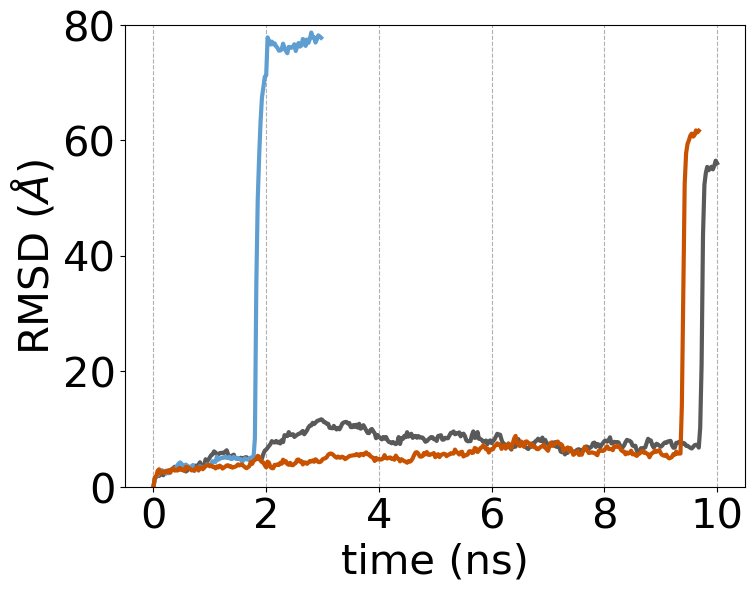

In [683]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ylabel('RMSD ($\AA$)',fontsize=30)
plt.xlabel('time (ns)',fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(np.arange(0,100,20),fontsize=30)
#plt.tick_params(labelbottom = False, bottom = False)
plt.grid(axis='x',ls='--')
plt.plot(rmsd_m1[1]/1000,rmsd_m1[3],lw=3,color='C3') #replicate1
plt.plot(rmsd_m1[1][0:120]/1000,rmsd_m2[3][0:120],lw=3,color='C4') #replicate2
plt.plot(rmsd_m1[1][0:388]/1000,rmsd_m3[3][0:388],lw=3,color='C5') #replicate3
plt.ylim(0,80)
plt.show()
#plt.savefig(path_out+'rmsd_martini_ph.svg',dpi=300,bbox_inches='tight')

In [684]:
bead1=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_o1_stride5.xtc')
bead2=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_o2_stride5.xtc')
bead3=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_o3_stride5.xtc')

/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [685]:
Rb1=MDAnalysis.analysis.rms.RMSD(bead1, reference=None, ref_frame=0,
                               select='resid 100 to 340 and not name H*',
                               groupselections=['resid 341 to 379 and not name H*'])
Rb1.run()

In [686]:
Rb2=MDAnalysis.analysis.rms.RMSD(bead2, reference=None, ref_frame=0,
                               select='resid 100 to 340 and not name H*',
                               groupselections=['resid 341 to 379 and not name H*'])
Rb2.run()

In [687]:
Rb3=MDAnalysis.analysis.rms.RMSD(bead3, reference=None, ref_frame=0,
                               select='resid 100 to 340 and not name H*',
                               groupselections=['resid 341 to 379 and not name H*'])
Rb3.run()

In [688]:
rmsd_b1=Rb1.rmsd.T
rmsd_b2=Rb2.rmsd.T
rmsd_b3=Rb3.rmsd.T

/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3741440372.py:3: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('RMSD ($\AA$)',fontsize=30)


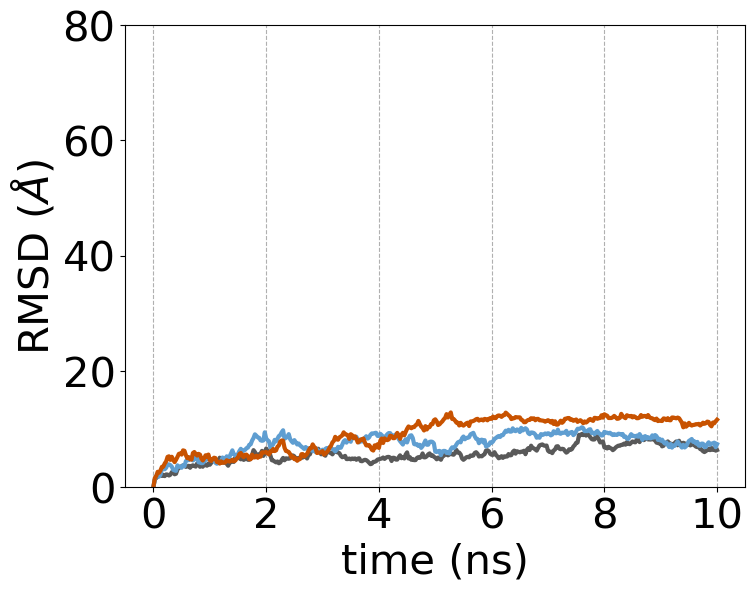

In [689]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,6))
plt.ylabel('RMSD ($\AA$)',fontsize=30)
plt.xlabel('time (ns)',fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(np.arange(0,100,20),fontsize=30)
plt.grid(axis='x',ls='--')
plt.plot(rmsd_b1[1]/1000,rmsd_b1[3],lw=3,color='C3') #replicate1
plt.plot(rmsd_b1[1]/1000,rmsd_b2[3],lw=3,color='C4') #replicate2
plt.plot(rmsd_b1[1]/1000,rmsd_b3[3],lw=3,color='C5') #replicate3
plt.ylim(0,80)
plt.show()
#plt.savefig(path_out+'rmsd_sb_ph.svg',dpi=300,bbox_inches='tight')

### SIGMA for metad

In [690]:
#!!MB
colv=np.loadtxt(path+'colvar_unbiased')

In [691]:
np.average(colv[:,5])

np.float64(2.322022646766169)

In [692]:
np.std(colv[:,5])/3,np.std(colv[:,5])/2,np.std(colv[:,5])

(np.float64(0.003587790585548336),
 np.float64(0.005381685878322504),
 np.float64(0.010763371756645008))

In [693]:
np.std(colv[:,5])/3

np.float64(0.003587790585548336)

### Metad

In [694]:
colv= plu.read_as_pandas(path+'colvar_metad_restr')

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/mbernetti/my_progs/miniconda3/lib/libplumedKernel.dylib" +++
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1703841389.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colv= plu.read_as_pandas(path+'colvar_metad_restr')


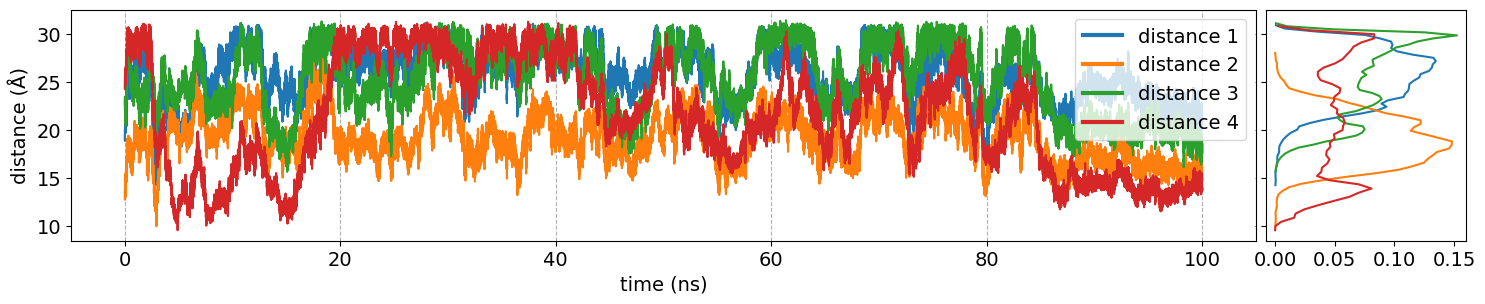

In [695]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(figsize=(18, 3))
ax.plot(colv["time"]/1000,colv["d1"]*10,label="distance 1",c="tab:blue")
ax.plot(colv["time"]/1000,colv["d2"]*10,label="distance 2",c="tab:orange")
ax.plot(colv["time"]/1000,colv["d3"]*10,label="distance 3",c="tab:green")
ax.plot(colv["time"]/1000,colv["d4"]*10,label="distance 4",c="tab:red")
plt.xlabel('time (ns)',fontsize=14)
plt.ylabel('distance (Å)',fontsize=14)
plt.grid(axis='x', ls='--')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

leg=plt.legend(fontsize=14, loc="upper right")  
for line in leg.get_lines():
    line.set_linewidth(3.0)

divider = make_axes_locatable(ax)
ax_histy = divider.append_axes("right", 2, pad=0.1, sharey=ax)

y,x=np.histogram(colv["d1"]*10,bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'tab:blue')
y,x=np.histogram(colv["d2"]*10,bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'tab:orange')
y,x=np.histogram(colv["d3"]*10,bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'tab:green')
y,x=np.histogram(colv["d4"]*10,bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'tab:red')
ax_histy.set_xticks([0.00,0.05,0.10,0.15])
plt.xticks(fontsize=14)
ax_histy.set_yticks([10,15,20,25,30])
plt.yticks(fontsize=0)

plt.show()
#plt.savefig(path_out+'dist_metad.svg', dpi=500, bbox_inches='tight')

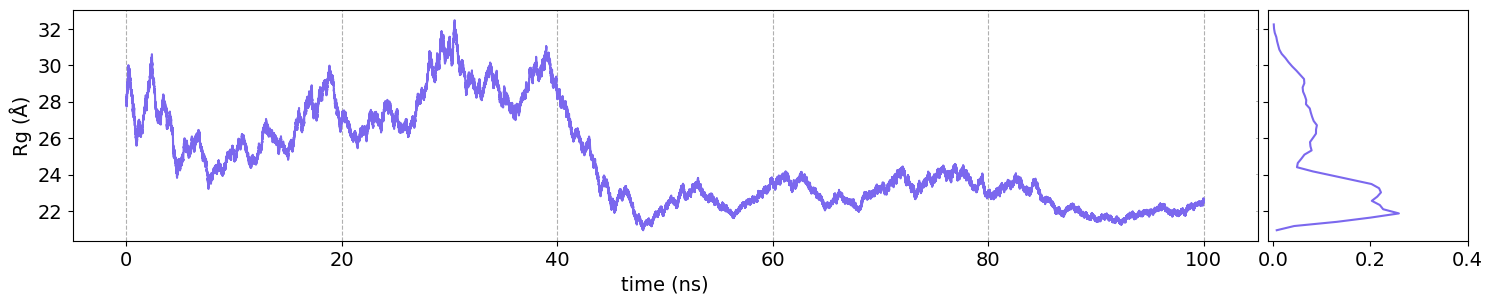

In [696]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(figsize=(18, 3))
plt.plot(colv["time"]/1000,colv["Rg"]*10,color='mediumslateblue')
plt.xlabel('time (ns)',fontsize=14)
plt.ylabel('Rg (Å)',fontsize=14)
plt.grid(axis='x', ls='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


divider = make_axes_locatable(ax)
ax_histy = divider.append_axes("right", 2, pad=0.1, sharey=ax)

y,x=np.histogram(colv["Rg"]*10,bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'mediumslateblue')
ax_histy.set_xticks([0,0.2,0.4])
plt.xticks(fontsize=14)
ax_histy.set_yticks([22,24,26,28,30,32])
plt.yticks(fontsize=0)

plt.show()
#plt.savefig(path_out+'Rg_metad.svg', dpi=500, bbox_inches='tight')

In [697]:
u=MDAnalysis.Universe(path+"protein_renum.pdb",path+"../../metad/output/whole_cen_mol_protein_100ns_vb.xtc")
ref=MDAnalysis.Universe(path+"protein_renum.pdb",path+"../../metad/output/whole_cen_mol_protein_100ns_vb.xtc")

/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [698]:
Cterm = MDAnalysis.analysis.rms.RMSD(u, reference=None,ref_frame=0,
                                 select="resid 100 to 340 and not name H*")
Cterm.run()

In [699]:
Nterm_all = MDAnalysis.analysis.rms.RMSD(u, reference=None,ref_frame=0,
                                 select="resid 1 to 99 and not name H*")
Nterm_all.run()

In [700]:
pept = MDAnalysis.analysis.rms.RMSD(u, reference=None,ref_frame=0,
                                 select="resid 341 to 379 and not name H*")
pept.run()    

In [701]:
Cterm.rmsd.T.shape

/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


(3, 20001)

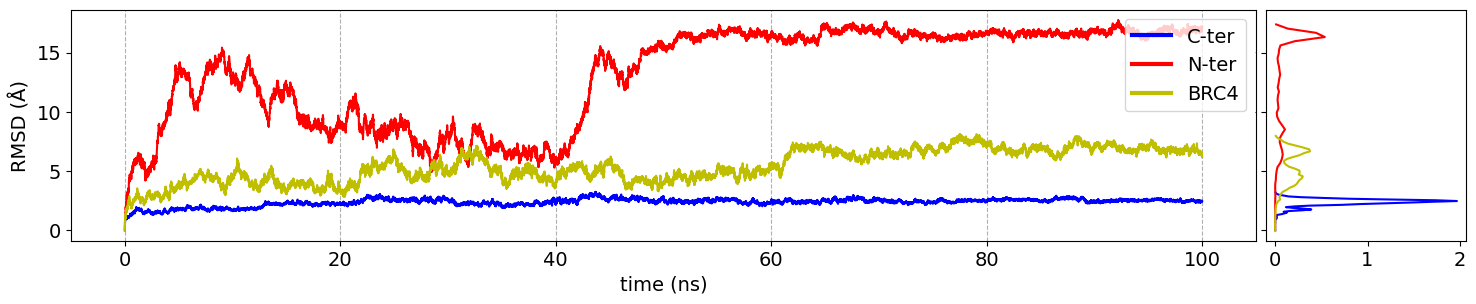

In [702]:
rmsdN_all = Nterm_all.rmsd.T
rmsdC = Cterm.rmsd.T
rmsdP = pept.rmsd.T
time = rmsdC[1]

from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(figsize=(18, 3))
ax.plot(time/1000, rmsdC[2], 'b-',  label="C-ter")
ax.plot(time/1000, rmsdN_all[2], 'r-',  label="N-ter")
ax.plot(time/1000, rmsdP[2], 'y-',  label="BRC4")
plt.xlabel('time (ns)',fontsize=14)
plt.ylabel('RMSD (Å)',fontsize=14)
plt.grid(axis='x', ls='--')
plt.xticks(fontsize=14)
plt.yticks([0.0,5.0,10,15],fontsize=14)

leg=plt.legend(fontsize=14, loc="upper right")  
for line in leg.get_lines():
    line.set_linewidth(3.0)

divider = make_axes_locatable(ax)
ax_histy = divider.append_axes("right", 2, pad=0.1, sharey=ax)

y,x=np.histogram(rmsdC[2],bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'b-')
y,x=np.histogram(rmsdN_all[2],bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'r-')
y,x=np.histogram(rmsdP[2],bins=50,density=True)
ax_histy.plot((y+y)/2,x[:-1],'y-')
ax_histy.set_xticks([0,1,2])
plt.xticks(fontsize=14)
ax_histy.set_yticks([0.0,5.0,10,15])
plt.yticks(fontsize=0)

plt.show()
#plt.savefig(path_out+'rmsd_metad.svg', dpi=500, bbox_inches='tight')

### Reweighting

#### Full version

In [703]:
colv_rew=np.loadtxt(path+'colvar_metad_restr_bias_100ns')
colv_rew.shape

(20001, 9)

In [704]:
weights=np.exp((colv_rew[:,-1]-np.max(colv_rew[:,-1]))/2.5) # avoid numeric overflow
weights=weights/np.sum(weights) # normalize

In [705]:
histo=np.histogram(colv_rew[:,5],bins=51,range=(2.0,3.3),weights=weights) 
histo_nw=np.histogram(colv_rew[:,5],bins=51,range=(2.0,3.3)) 

/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3683275987.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo_nw[1][:-1]+histo_nw[1][1:])/2,(-2.5*np.log(histo_nw[0])-np.min(-2.5*np.log(histo_nw[0])))/4.184,label='non weighted')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3683275987.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')


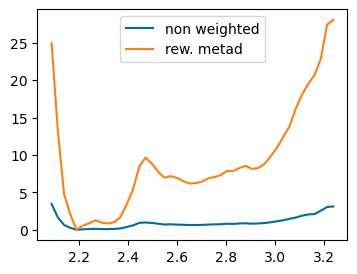

In [706]:
plt.plot((histo_nw[1][:-1]+histo_nw[1][1:])/2,(-2.5*np.log(histo_nw[0])-np.min(-2.5*np.log(histo_nw[0])))/4.184,label='non weighted')
plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')
plt.legend()
plt.show()

In [707]:
spectra_ob=np.loadtxt(path+'colvar_onebead_DRIVER_SolvStride1')
spectra_ob.shape

(20001, 55)

In [708]:
qs=exp_whole[selected_points,0]
exp=uf_exp_whole[selected_points]
scale_exp=np.exp(intercept)

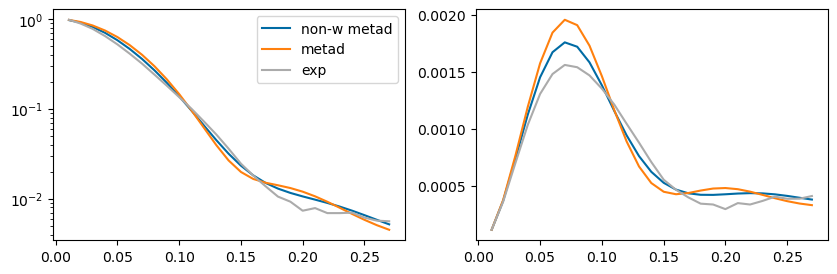

In [709]:
plt.figure(figsize=(10,3))
plt.tight_layout()
plt.subplot(1,2,1)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0),label='non-w metad')
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=weights),label='metad')
plt.plot(qs,exp/scale_exp,label='exp')
plt.yscale('log')
plt.legend()
plt.subplot(1,2,2)
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0))
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=weights))
plt.plot(qs,exp/scale_exp*qs**2,label='exp')
plt.show()

In [710]:
# Maxent function:
def Gamma(l,metadb,observables,e,sigma=0.0):
    l = np.array(l)
    weight_all = metadb / 2.5 # metadb is the array of metadynamics bias associated with each frame (assigned using the total final bias)
    weight_all -= np.dot(observables,l) # lamba*s inside the exponential of the maxent formula
    shift_all = np.max(weight_all) # shift to be subtracted to avoid numerical overflow problems in the exponential
    weight_all = np.exp(weight_all - shift_all)

    weight_mt = metadb / 2.5 
    shift_mt = np.max(weight_mt) # shift to be subtracted to avoid numerical overflow problems in the exponential
    weight_mt = np.exp(weight_mt - shift_mt)

    f = np.log(np.sum(weight_all) / np.sum(weight_mt)) + shift_all - shift_mt + np.dot(l,e)
    der = e - np.dot(weight_all,observables) / np.sum(weight_all) # derivative with respect to l
    reg=sigma**2 # regularization term
    f+=0.5*np.sum(reg*l**2)
    der+=reg*l
    
    return(f,der)

def weights_noprop(l,metadb,observables,e):
    l = np.array(l)
    weight_all = metadb / 2.5
    obs_prop=observables - e
    #print(observables[0],obs_prop[0])

    weight_all -= np.dot(obs_prop,l) # lamba*s inside the exponential of the maxent formula
    shift_all = np.max(weight_all) # shift to be subtracted to avoid numerical overflow problems in the exponential
    weight_all = np.exp(weight_all - shift_all) 

    return weight_all/ np.sum(weight_all)

__Sanity check__ of the maxent function, using the __metad spectrum__ (instead of the exp.)  as target for maxent. This should return the original weights of the metad:

In [711]:
res = minimize(Gamma, np.zeros(qs.shape), method='BFGS',tol=1e-10,jac=True,
           args=(colv_rew[:,-1],spectra_ob[:,1:28],np.average(spectra_ob[:,1:28],axis=0,weights=weights),1e-10)) 

In [712]:
w_me = weights_noprop(res.x,colv_rew[:,-1],spectra_ob[:,1:28],np.average(spectra_ob[:,1:28],axis=0,weights=weights))

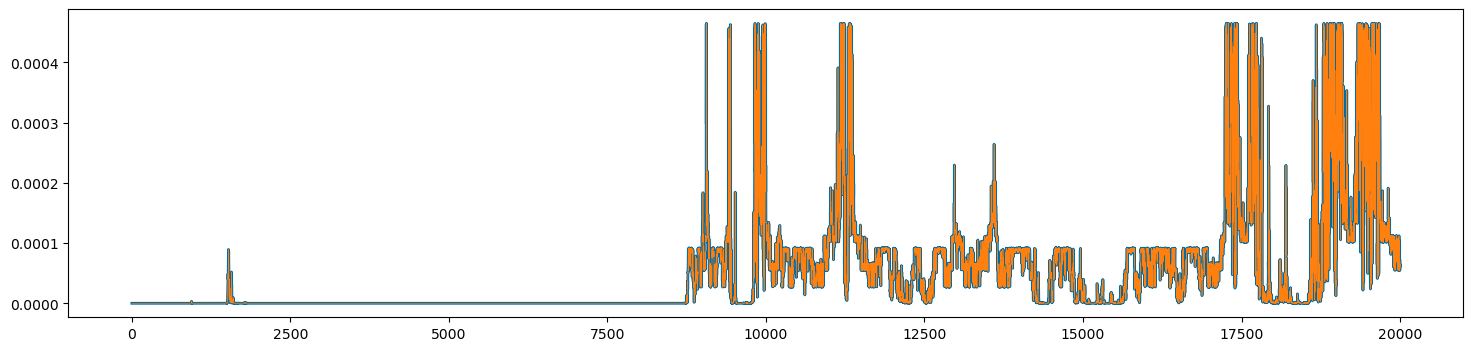

In [713]:
plt.figure(figsize=(18,4))
plt.plot(w_me,lw=2)
plt.plot(weights,lw=0.5)
#plt.xlim(0,2e4)
plt.show()

In [714]:
sigmas=np.array([1e-10,1e-4,4e-4,5e-4,6e-4,8e-4,1e-3,2e-3,3e-3,4e-3,5e-3,1e-2,3e-2,5e-2,1e-1,1,1e1,1e2,1e3])
kishes={}
w_me={}
for i in range(len(sigmas)):
    res_i = minimize(Gamma, np.zeros(qs.shape), method='BFGS',tol=1e-10,jac=True,
                   args=(colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp,sigmas[i]))
    w_me_i = weights_noprop(res_i.x,colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp)
    w_me[sigmas[i]] = w_me_i # w_me.append(w_me_i)
    kish_i = 1 / np.sum(w_me_i**2)
    kishes[sigmas[i]] = kish_i # kishes.append(kish_i)
    print('Done with sigma=%s, kish size=%s'%(sigmas[i],kish_i))

Done with sigma=1e-10, kish size=1.0
Done with sigma=0.0001, kish size=2.826425905274889
Done with sigma=0.0004, kish size=18.190022963645998
Done with sigma=0.0005, kish size=41.73513842276102
Done with sigma=0.0006, kish size=77.73500218623272
Done with sigma=0.0008, kish size=168.21519178718665
Done with sigma=0.001, kish size=290.12006892461727
Done with sigma=0.002, kish size=1295.5695925013026
Done with sigma=0.003, kish size=2411.719398799905
Done with sigma=0.004, kish size=3181.475429961568
Done with sigma=0.005, kish size=3659.493996149552
Done with sigma=0.01, kish size=4611.99244483162
Done with sigma=0.03, kish size=7391.066108171931
Done with sigma=0.05, kish size=8571.734213217345
Done with sigma=0.1, kish size=7425.086083851755
Done with sigma=1.0, kish size=5032.778602713879
Done with sigma=10.0, kish size=4997.934650679551
Done with sigma=100.0, kish size=4997.586974054061
Done with sigma=1000.0, kish size=4997.583497369573


In [715]:
w_me.keys()

dict_keys([np.float64(1e-10), np.float64(0.0001), np.float64(0.0004), np.float64(0.0005), np.float64(0.0006), np.float64(0.0008), np.float64(0.001), np.float64(0.002), np.float64(0.003), np.float64(0.004), np.float64(0.005), np.float64(0.01), np.float64(0.03), np.float64(0.05), np.float64(0.1), np.float64(1.0), np.float64(10.0), np.float64(100.0), np.float64(1000.0)])

In [716]:
kishe_sizes=np.array([kishes[a] for a in sigmas])

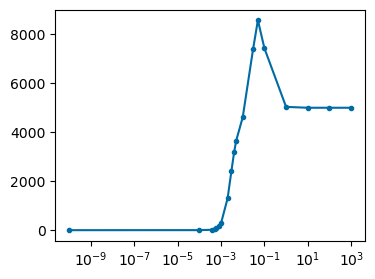

In [717]:
plt.plot(sigmas,kishe_sizes,'.-')
plt.xscale('log')
plt.show()

In [718]:
exp_error=exp_whole[selected_points,2]/scale_exp # normalize the residuals by exp. error

In [719]:
# find sigma that ~ minimizes overfitting (chi squared close to 1)
sigmas=np.array([5e-3,1e-2,2e-2,3e-2,3.5e-2,4e-2,5e-2])
for i in range(len(sigmas)):
    res_i = minimize(Gamma, np.zeros(qs.shape), method='BFGS',tol=1e-10,jac=True,
                   args=(colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp,sigmas[i]))
    w_me_i = weights_noprop(res_i.x,colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp)
    kish_i = 1 / np.sum(w_me_i**2)
    # error (bootstrap) on the spectra: MAXENT weights
    nb=10 # N blocks, applies to both weights and spectra arrays
    npt=27 # N points per observable: saxs spectra have 51 q points in my case
    weights_me=copy.deepcopy(w_me_i[:-1]) # remove last to allow division by 10..
    weights_me=weights_me.reshape((nb,-1)) # weights
    spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
    spectra=spectra.reshape((nb,-1,npt))
    obs_j=[]
    for b in range(400):
        shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
        resamp_w=weights_me[shuffle][:,:].reshape((-1)) # resampled weights
        resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
        rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
        # 
        obs_j.append(rew_s)
    obs_j=np.array(obs_j)
    err_maxent_i=np.std(obs_j,axis=0)
    # print 
    print('sigma=%s, kish size=%s, chi squared=%s'%(
        sigmas[i],kish_i,1/(qs.shape[0]-1)*np.sum(((np.average(spectra_ob[:,1:28],axis=0,weights=w_me_i)-(exp/scale_exp))/np.sqrt(exp_error**2+err_maxent_i**2))**2)))

sigma=0.005, kish size=3659.493996149552, chi squared=0.18452212644717952
sigma=0.01, kish size=4611.99244483162, chi squared=0.2365568681221858
sigma=0.02, kish size=5766.356163876318, chi squared=0.3978922142005429
sigma=0.03, kish size=7391.066108171931, chi squared=0.8680241969676006
sigma=0.035, kish size=8209.460677583087, chi squared=1.2123798348720107
sigma=0.04, kish size=8779.595655252013, chi squared=1.7791642749600665
sigma=0.05, kish size=8571.734213217345, chi squared=4.472040974668137


In [720]:
chosen_s=3e-2
chosen_s

0.03

In [721]:
kishes[chosen_s]

np.float64(7391.066108171931)

In [722]:
kishes[chosen_s],spectra_ob.shape[0],kishes[chosen_s]/spectra_ob.shape[0]

(np.float64(7391.066108171931), 20001, np.float64(0.3695348286671632))

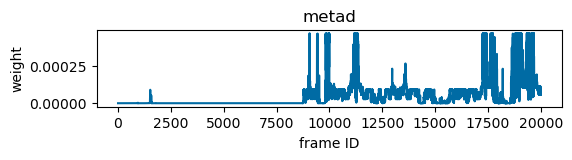

In [723]:
plt.figure(figsize=(6,1))
plt.plot(weights)
plt.ylabel('weight')
plt.xlabel('frame ID')
plt.title('metad')
plt.show()
#plt.savefig(path_out+"/metad_weights_20000.png",dpi=300,bbox_inches="tight")

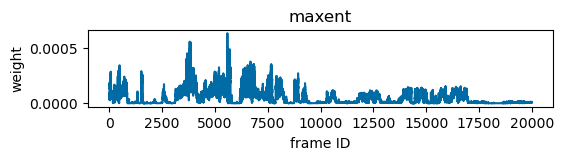

In [724]:
plt.figure(figsize=(6,1))
plt.plot(w_me[chosen_s])
plt.ylabel('weight')
plt.xlabel('frame ID')
plt.title('maxent')
plt.show()
#plt.savefig(path_out+"/maxent_weights_20000.png",dpi=300,bbox_inches="tight")

In [725]:
np.sum(w_me[chosen_s])

np.float64(1.0)

#### Save the maxent weights in both binary and human-readable formats

In [531]:
pickle.dump(w_me[chosen_s],open(path_out+"/maxent_weights_sigma%s.dat"%chosen_s, "wb"))

In [533]:
np.savetxt(path_out+"/maxent_weights_sigma%s.txt"%chosen_s,w_me[chosen_s])

#### Use the maxent weights for analyses

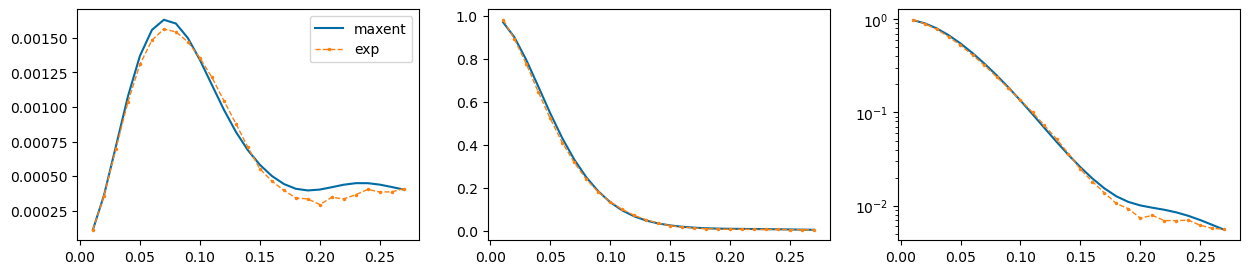

In [726]:
plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),label='maxent')
plt.plot(qs,exp/scale_exp*qs**2,'.--',lw=1,ms=3,label='exp')
plt.legend()

plt.subplot(1,3,2)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent')
plt.plot(qs,(exp/scale_exp),'.--',lw=1,ms=3,label='exp')

plt.subplot(1,3,3)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent')
plt.plot(qs,(exp/scale_exp),'.--',lw=1,ms=3,label='exp')
plt.yscale('log')
plt.show()

In [727]:
histo_me=np.histogram(colv_rew[:,5],bins=51,range=(2.0,3.3),weights=w_me[chosen_s])

<>:8: SyntaxWarning: invalid escape sequence '\A'
<>:8: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2954398020.py:8: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Rg ($\AA$)',fontsize=16)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2954398020.py:5: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo[1][:-1]+histo[1][1:])/2*10,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='metad',c='crimson',lw=3)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2954398020.py:6: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2*10,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='maxent',c="C2",lw=3)


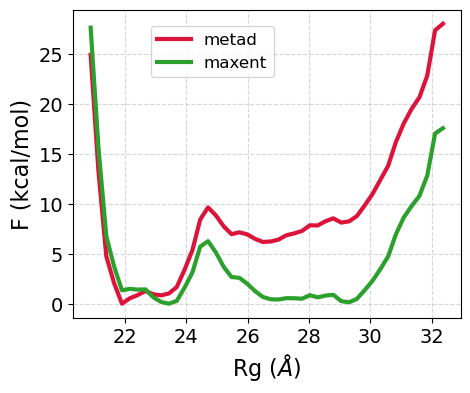

In [728]:
plt.figure(figsize=(5,4))
#plt.style.use('tableau-colorblind10')
plt.style.use('default')
plt.grid(ls='--',alpha=0.5)
plt.plot((histo[1][:-1]+histo[1][1:])/2*10,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='metad',c='crimson',lw=3)
plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2*10,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='maxent',c="C2",lw=3)
plt.ylabel('F (kcal/mol)',fontsize=16)
plt.xlabel('Rg ($\AA$)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12,loc=(0.2,0.78))
plt.show()
#plt.savefig(path_out+"/FE.png",dpi=600,bbox_inches="tight")

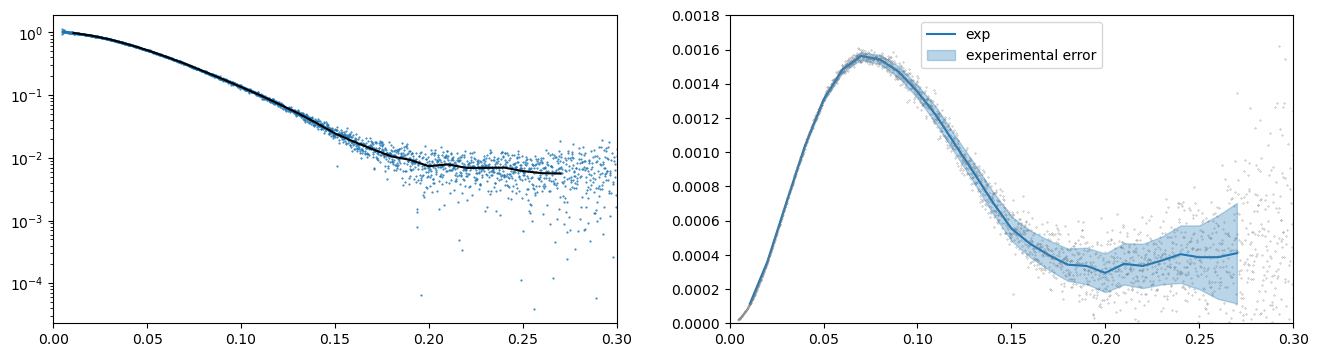

In [729]:
plt.figure(figsize=(16,4))
plt.tight_layout()

plt.subplot(1,2,1)
plt.plot(exp_whole[:,0],exp_whole[:,1]/scale_exp,'.',ms=1)
plt.plot(qs,exp/scale_exp,color='black')
plt.yscale('log')
plt.xlim(0,0.3)

plt.subplot(1,2,2)
plt.plot(qs,(exp/scale_exp)*qs**2,label='exp')

plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 ((exp+exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 color='C0',label='experimental error',zorder=10,alpha=0.3)
plt.plot(exp_whole[:,0],(exp_whole[:,1]/scale_exp)*exp_whole[:,0]**2,'.',ms=0.5,color='grey')
plt.ylim(0,1.8e-3)
plt.xlim(0,0.3)
plt.legend()

plt.show()

In [730]:
# error (bootstrap) on the spectra: MAXENT weights
# error
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_me=copy.deepcopy(w_me[chosen_s][:-1]) # remove last to allow division by 10..
weights_me=weights_me.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_me[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    obs_j.append(rew_s)
obs_j=np.array(obs_j)
err_maxent=np.std(obs_j,axis=0)

In [731]:
# error (bootstrap) on the spectra: METAD weights
# error
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_metad=copy.deepcopy(weights[:-1]) # remove last to allow division by 10..
weights_metad=weights_metad.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_metad[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    obs_j.append(rew_s)
obs_j=np.array(obs_j)
err_metad=np.std(obs_j,axis=0)

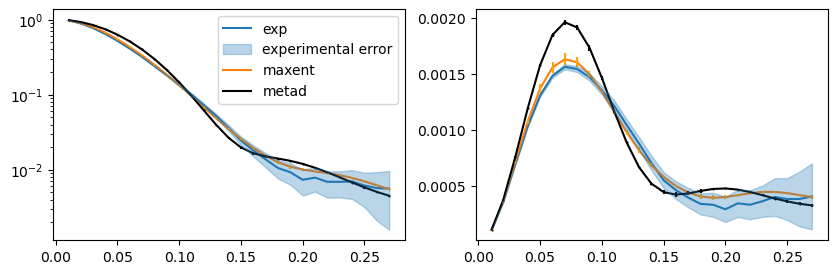

In [732]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(qs,(exp/scale_exp),label='exp')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp),
                 ((exp+exp_whole[selected_points,2])/scale_exp),
                 color='C0',label='experimental error',zorder=10,alpha=0.3)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent')
plt.errorbar(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),yerr=err_maxent,fmt='.',ms=1,color='orange')
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=weights),label='metad',color='black')
plt.errorbar(qs,np.average(spectra_ob[:,1:28],axis=0,weights=weights),yerr=err_metad,fmt='.',ms=1,color='black')
plt.legend()
plt.yscale('log')
plt.legend()

plt.subplot(1,2,2)
plt.plot(qs,(exp/scale_exp)*qs**2,label='exp')
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),label='maxent')
plt.errorbar(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),yerr=err_maxent*qs**2,fmt='.',ms=1,color='orange')
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=weights),label='metad',color='black')
plt.errorbar(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=weights),yerr=err_metad*qs**2,fmt='.',ms=1,color='black')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 ((exp+exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 color='C0',label='experimental error',zorder=10,alpha=0.3)


plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:26: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:26: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1436036012.py:6: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=14)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1436036012.py:7: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=14)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/1436036012.py:26: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=14)


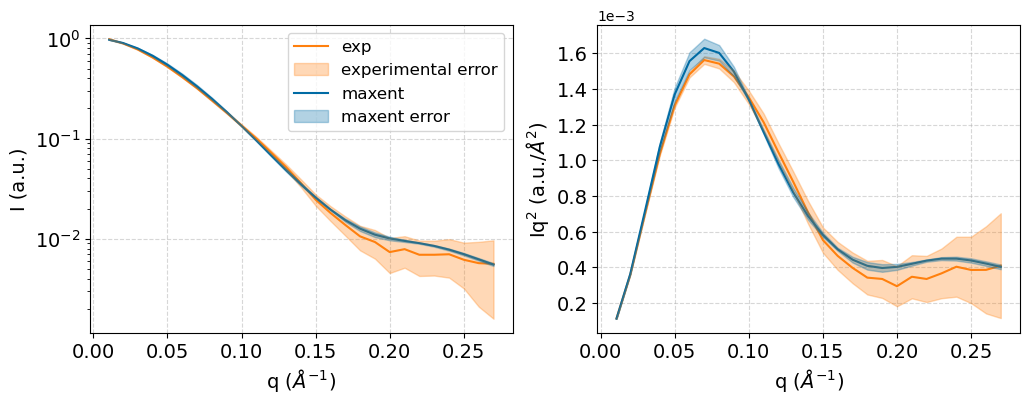

In [733]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,4))
#plt.figure(figsize=(6.7,2.6))
plt.subplot(1,2,2)
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=14)
plt.xlabel('q ($\AA^{-1}$)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(ls='--',alpha=0.5)
plt.plot(qs,(exp/scale_exp)*qs**2,label='exp',color='C1')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 ((exp+exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 color='C1',label='experimental error',zorder=10,alpha=0.3)
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),label='maxent',color='C0')
plt.fill_between(exp_whole[selected_points,0],
                 (np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])-err_maxent)*exp_whole[selected_points,0]**2,
                 (np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])+err_maxent)*exp_whole[selected_points,0]**2,
                 color='C0',label='maxent error',zorder=10,alpha=0.3)
#plt.legend(fontsize=13)

plt.subplot(1,2,1)
plt.grid(ls='--',alpha=0.5)
plt.ylabel('I (a.u.)',fontsize=14)
plt.xlabel('q ($\AA^{-1}$)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.plot(qs,(exp/scale_exp),label='exp',color='C1')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp),
                 ((exp+exp_whole[selected_points,2])/scale_exp),
                 color='C1',label='experimental error',zorder=10,alpha=0.3)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent',color='C0')
plt.fill_between(exp_whole[selected_points,0],
                 (np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])-err_maxent),
                 (np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])+err_maxent),
                 color='C0',label='maxent error',zorder=10,alpha=0.3)

plt.yscale('log')
plt.legend(fontsize=12)
plt.show()
#plt.savefig(path_out+"/maxent_spectra_20000_paper.png",dpi=1200,bbox_inches="tight")

In [734]:
# chi squared, computed-exp: CONSISTENT WITH PRIMUS
1/(qs.shape[0]-1)*np.sum(((np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])-(exp/scale_exp))/np.sqrt(exp_error**2+err_maxent**2))**2)

np.float64(0.8600879319191976)

In [735]:
# error (bootstrap) on the spectra: MAXENT weights
# error on the residuals
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_me=copy.deepcopy(w_me[chosen_s][:-1]) # remove last to allow division by 10..
weights_me=weights_me.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_me[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    residuals_i=(((exp/scale_exp)-rew_s)/np.sqrt(exp_error**2+err_maxent**2)) # (((exp/scale_exp)-rew_s)/exp_error) 
    obs_j.append(residuals_i)
obs_j=np.array(obs_j)
err_maxent_residuals=np.std(obs_j,axis=0)

<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\A'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3912893503.py:10: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta$I/$\sigma$',fontsize=17)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3912893503.py:11: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=17)


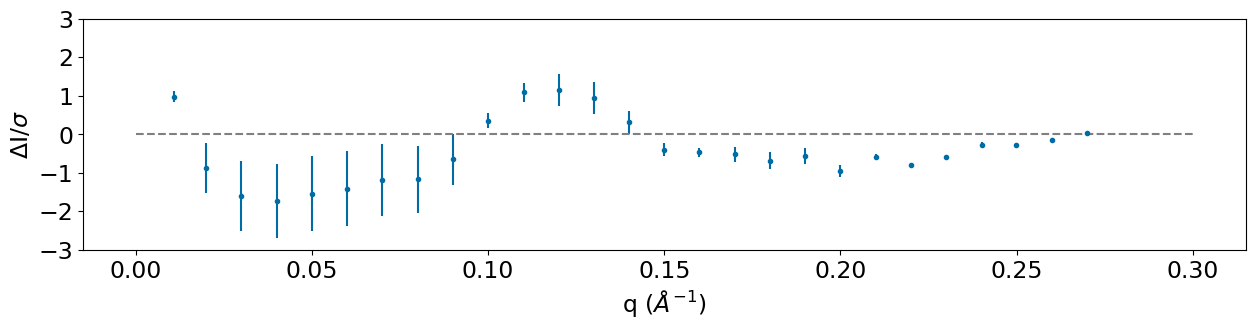

In [736]:
# CONSISTENT with primus + error (via bootstrap) on the calculated spectrum 
plt.figure(figsize=(15,3))
plt.style.use('tableau-colorblind10')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
exp_error=exp_whole[selected_points,2]/scale_exp # normalize the residuals by exp. error (!!DOUBLE CHECK ERROR PROPAGATION!!)
#plt.plot(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]))/np.sqrt(exp_error**2+err_maxent**2),'o')
plt.errorbar(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]))/np.sqrt(exp_error**2+err_maxent**2),yerr=err_maxent_residuals,fmt='.',label='rew. maxent')
plt.hlines(0,0,0.3,ls='--',color='grey')
plt.ylabel('$\Delta$I/$\sigma$',fontsize=17)
plt.xlabel('q ($\AA^{-1}$)',fontsize=17)
plt.ylim(-3,3)
plt.show()
#plt.savefig(path_out+'residuals.svg',dpi=300,bbox_inches='tight')

In [737]:
# error (bootstrap) on the spectra: METAD weights
# error on the residuals
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_metad=copy.deepcopy(weights[:-1]) # remove last to allow division by 10..
weights_metad=weights_metad.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_metad[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    residuals_i=(((exp/scale_exp)-rew_s)/np.sqrt(exp_error**2+err_metad**2)) # ((rew_s-(exp/scale_exp))/exp_error)
    obs_j.append(residuals_i)
obs_j=np.array(obs_j)
err_metad_residuals=np.std(obs_j,axis=0)

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3213149322.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('${\Delta}I/{\sigma}$')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3213149322.py:8: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)')


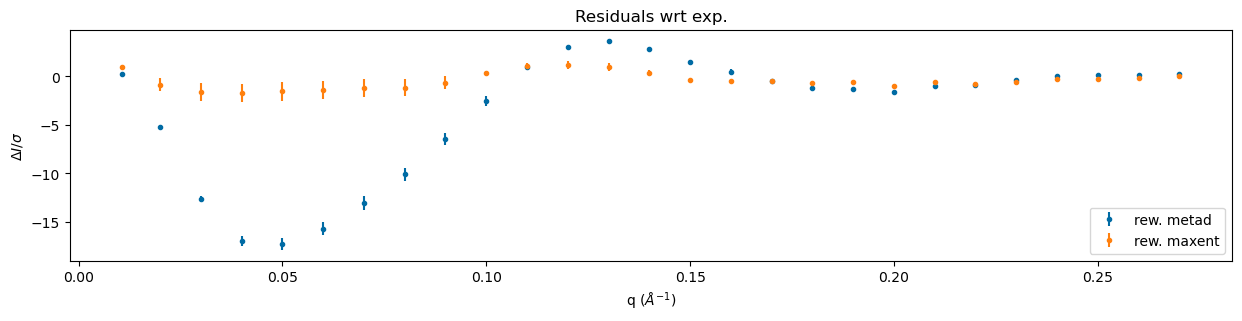

In [738]:
# normalized difference, with statistical error
exp_error=exp_whole[selected_points,2]/scale_exp
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(15,3))
plt.errorbar(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=weights))/np.sqrt(exp_error**2+err_metad**2),yerr=err_metad_residuals,fmt='.',label='rew. metad')
plt.errorbar(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]))/np.sqrt(exp_error**2+err_maxent**2),yerr=err_maxent_residuals,fmt='.',label='rew. maxent')
plt.ylabel('${\Delta}I/{\sigma}$')
plt.xlabel('q ($\AA^{-1}$)')
plt.title('Residuals wrt exp.')
plt.legend()
plt.show()
#plt.savefig(path_out+'residuals_si.svg',dpi=300,bbox_inches='tight')

### Compute populations

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2311887037.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Rg ($\AA$)')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2311887037.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2311887037.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='rew. maxent')


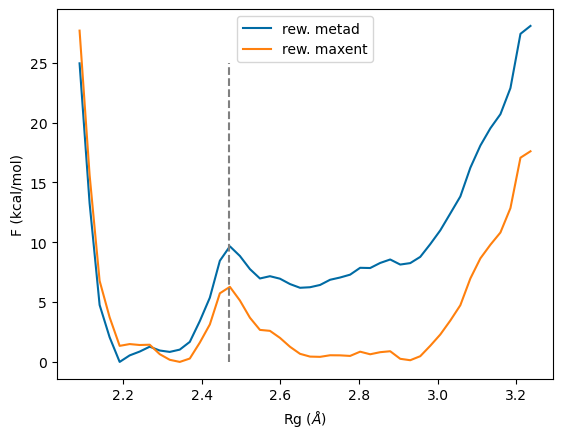

In [739]:
plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')
plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='rew. maxent')
plt.vlines(2.47,0,25,ls='--',color='grey')
plt.ylabel('F (kcal/mol)')
plt.xlabel('Rg ($\AA$)')
plt.legend()
plt.show()

In [740]:
# extended populations (Rg>2.47)
# maxent, metad
np.sum(w_me[chosen_s][np.where(colv_rew[:,5]>2.47)]),np.sum(weights[np.where(colv_rew[:,5]>2.47)])

(np.float64(0.646888424651887), np.float64(6.345588513184506e-05))

In [741]:
# compact populations (Rg<2.47)
# maxent, metad
np.sum(w_me[chosen_s][np.where(colv_rew[:,5]<2.47)]),np.sum(weights[np.where(colv_rew[:,5]<2.47)])

(np.float64(0.353111575348113), np.float64(0.9999365441148682))

## Contacts

In [742]:
#traj=mdt.load(path+'whole_cen_mol_protein_100ns_vb.xtc',top=path+'last_frame_replicate1_protein.pdb')
traj=mdt.load(path+'../../metad/output/whole_cen_mol_protein_100ns_vb.xtc',top=path+'last_frame_replicate1_protein.pdb')

In [743]:
traj

<mdtraj.Trajectory with 20001 frames, 5829 atoms, 379 residues, and unitcells at 0x10f25c380>

In [744]:
table, bonds = traj.top.to_dataframe()

In [745]:
chainA_idx=np.where(table['chainID'].to_numpy()==0)[0]

Nter: 24 to 84 counting from 1, thus 23 to 83 i.e. [23:84]  
Brc4: 340 to 378 i.e. [340:379]

In [391]:
ctcs=mdt.compute_contacts(traj,contacts=[[23, 339], [0, 378]],scheme='closest-heavy')

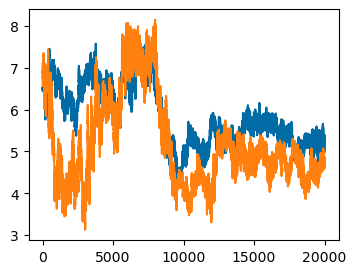

In [392]:
plt.plot(ctcs[0][:,0])
plt.plot(ctcs[0][:,1])

In [167]:
brc4_grp=np.array(list(itertools.product(np.arange(340,379,1),np.arange(23,84,1))))
brc4_grp.shape

(2379, 2)

In [168]:
brc4_grp_allN=np.array(list(itertools.product(np.arange(340,379,1),np.arange(0,84,1))))
brc4_grp_allN.shape

(3276, 2)

In [95]:
brc4_ctc=mdt.compute_contacts(traj,contacts=brc4_grp,scheme='closest-heavy')

In [96]:
start=datetime.datetime.now()

brc4_ctc_allN=mdt.compute_contacts(traj,contacts=brc4_grp_allN,scheme='closest-heavy')

end=datetime.datetime.now()
tdelta=end-start
print("total seconds:",tdelta.total_seconds())

total seconds: 363.674327


In [97]:
np.unique(brc4_ctc[1][:,0]).shape,np.unique(brc4_ctc[1][:,1]).shape

((39,), (61,))

In [98]:
brc4_ctc_filt=1*(brc4_ctc[0]<0.5)

In [99]:
brc4_ctc_allN_filt=1*(brc4_ctc_allN[0]<0.5)

In [100]:
brc4_ctc_filt_resh=brc4_ctc_filt.reshape(brc4_ctc_filt.shape[0],-1,61)

In [101]:
brc4_ctc_allN_filt_resh=brc4_ctc_allN_filt.reshape(brc4_ctc_allN_filt.shape[0],-1,84)

In [169]:
nter_grp=np.array(list(itertools.product(np.arange(23,84,1),np.arange(340,379,1))))

In [170]:
nter_grp_allN=np.array(list(itertools.product(np.arange(0,84,1),np.arange(340,379,1))))

In [104]:
start=datetime.datetime.now()

nter_ctc=mdt.compute_contacts(traj,contacts=nter_grp,scheme='closest-heavy')

end=datetime.datetime.now()
tdelta=end-start
print("total seconds:",tdelta.total_seconds())

total seconds: 266.887812


In [105]:
nter_ctc_filt=1*(nter_ctc[0]<0.5)

In [106]:
nter_ctc_filt_resh=nter_ctc_filt.reshape(nter_ctc_filt.shape[0],-1,39)

In [171]:
chainA_idx=np.where(table['chainID'].to_numpy()==0)[0]
chainB_idx=np.where(table['chainID'].to_numpy()==1)[0]

In [172]:
# residue.index counts from 0, residue.resSeq counts as the pdb (e.g. from 1), compute_contacts considers residues 0-indexed
nter_residues=[a.residue for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(24,84,61,dtype=int)] # resids 24 to 84
brc4_residues=[a.residue for a in traj.top.atoms if a.index in chainB_idx if a.name=='CA' if a.residue.resSeq in np.linspace(1,39,40,dtype=int)] 

In [173]:
# residue.index counts from 0, residue.resSeq counts as the pdb (e.g. from 1), compute_contacts considers residues 0-indexed
nter_allN_residues=[a.residue for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(0,84,85,dtype=int)]
cter_allN_residues=[a.residue for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(84,340,256,dtype=int)]

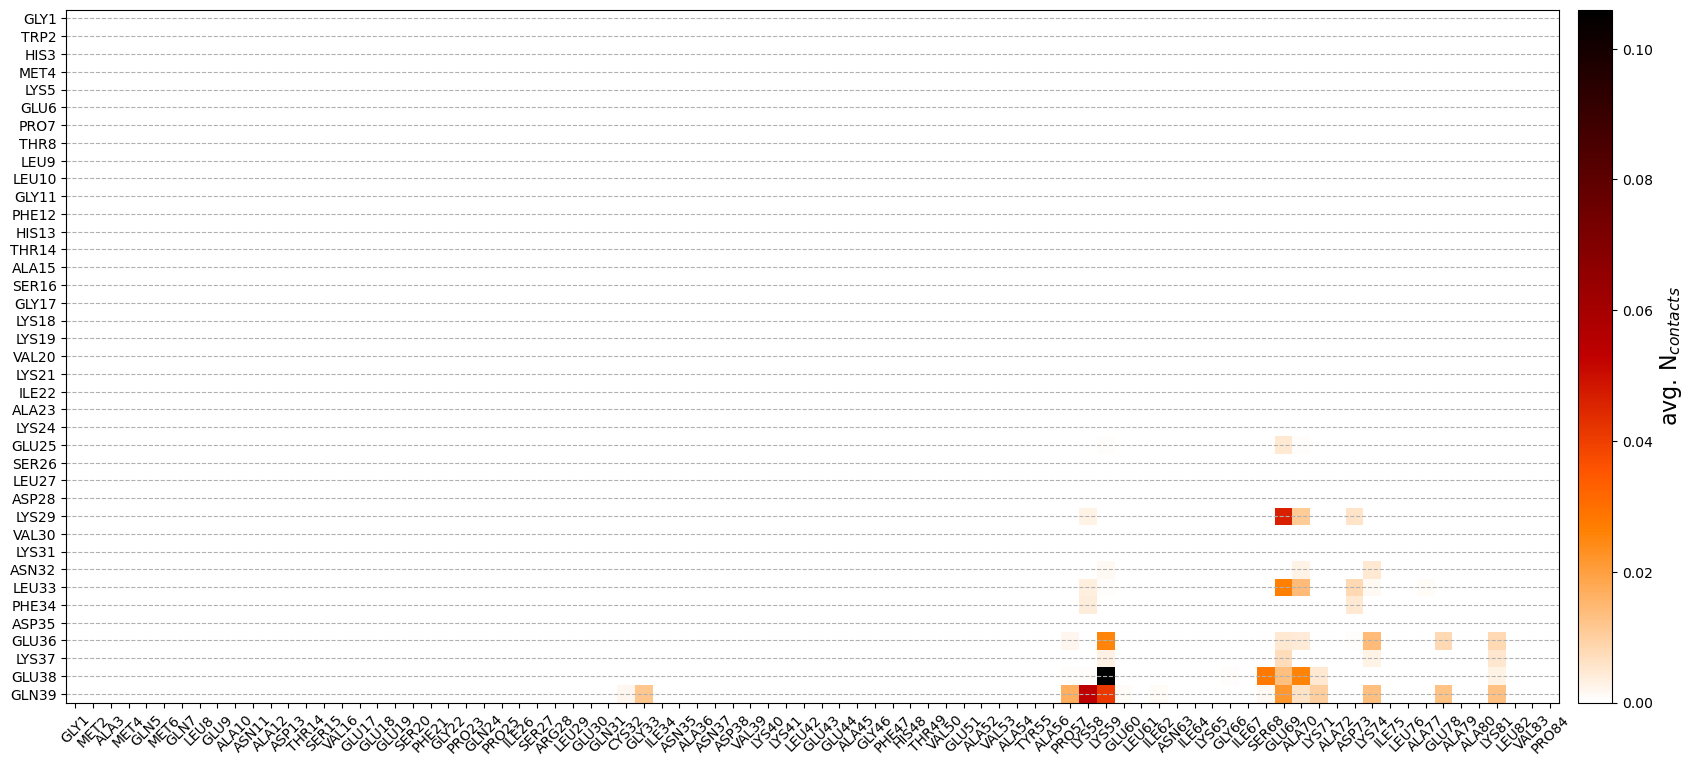

In [205]:
from matplotlib import colormaps
plt.figure(figsize=(24,9))
cmap = colormaps['gist_heat_r']
plt.imshow(np.average(brc4_ctc_allN_filt_resh,axis=0,weights=w_me[chosen_s]),cmap)
plt.colorbar(orientation="vertical",pad=0.01).ax.set_ylabel('avg. N$_{contacts}$', fontsize=16)
plt.yticks(np.linspace(0,38,39),brc4_residues)
plt.xticks(np.linspace(0,83,84),nter_allN_residues,rotation=45)
plt.grid(axis='y',ls='--')
plt.savefig(path_out+'contacts_matrix_new_heat.png',dpi=300,bbox_inches='tight')

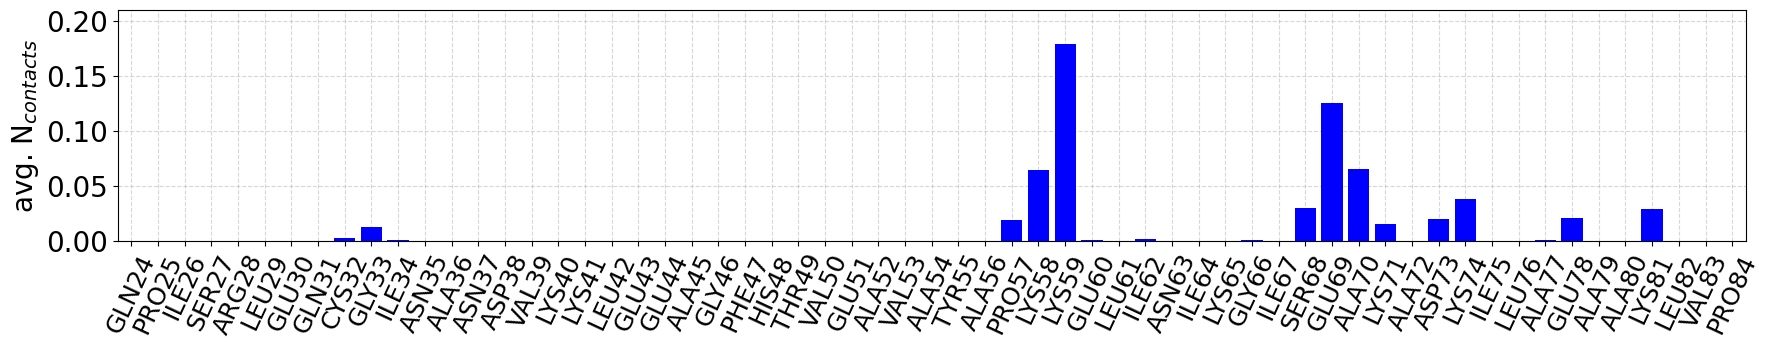

In [111]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(21,3))
plt.bar(np.linspace(0,60,61),np.average(np.sum(nter_ctc_filt_resh,axis=2),axis=0,weights=w_me[chosen_s]),width=0.8,zorder=10,color='blue')
plt.xticks(np.linspace(0,60,61),nter_residues,rotation=65,fontsize=18)
plt.xlim(-0.5,60.5)
plt.ylim(0,0.21)
plt.ylabel('avg. N$_{contacts}$',fontsize=20)
plt.yticks(fontsize=20)
plt.grid(ls='--',alpha=0.5)
plt.savefig(path_out+'contacts_nter.svg',dpi=300,bbox_inches='tight')
plt.show()

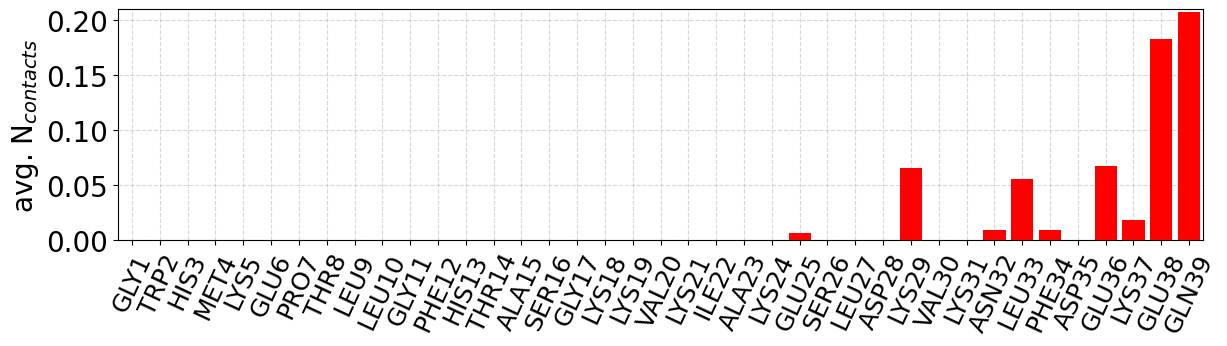

In [112]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(14,3))
plt.bar(np.linspace(0,38,39),np.average(np.sum(brc4_ctc_filt_resh,axis=2),axis=0,weights=w_me[chosen_s]),width=0.8,zorder=10,color='red')
plt.xticks(np.linspace(0,38,39),brc4_residues,rotation=65,fontsize=18)
plt.yticks(fontsize=20)
plt.xlim(-0.5,38.5)
plt.ylim(0,0.21)
plt.ylabel('avg. N$_{contacts}$',fontsize=20)
plt.grid(ls='--',alpha=0.5)
plt.savefig(path_out+'contacts_brc4.svg',dpi=300,bbox_inches='tight')
plt.show()

## Clustering

### PCA

In [174]:
chainB_ca_idx=np.array([a.index for a in traj.top.atoms if a.index in chainB_idx if a.name=='CA'])
chainB_ca_idx.shape

(39,)

In [175]:
# N-ter CA
nter_ca_idx=np.array([a.index for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(1,84,84,dtype=int)]) # resids 1 to 84
loop_ca_idx=np.array([a.index for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(85,99,15,dtype=int)]) # resids 85 to 99
cter_ca_idx=np.array([a.index for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(100,340,241,dtype=int)]) # resids 100 to 340

In [176]:
chainB_ca_idx=chainB_ca_idx[:] #whole selection

In [177]:
# alignment on C-ter CA
traj.superpose(traj, frame=0, atom_indices=cter_ca_idx)

<mdtraj.Trajectory with 20001 frames, 5829 atoms, 379 residues, and unitcells at 0x10cf93d90>

In [178]:
chain_A=np.array([a.index for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(1,340,340,dtype=int)])

In [179]:
whole_sel=np.concatenate((chain_A,chainB_ca_idx))
chain_A.shape,chainB_ca_idx.shape,whole_sel.shape

((340,), (39,), (379,))

In [180]:
cleaned_coords=traj.xyz[:,whole_sel,:]
cleaned_coords.shape

(20001, 379, 3)

In [181]:
pca = PCA()

In [182]:
traj_reshaped=cleaned_coords.reshape(traj.n_frames, -1)
traj_reshaped.shape

(20001, 1137)

In [183]:
pca_xyz = pca.fit_transform(traj_reshaped)
pca_xyz.shape

(20001, 1137)

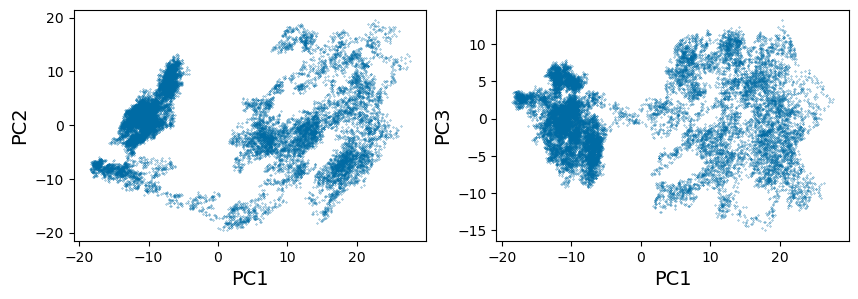

In [184]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(pca_xyz[:,0],pca_xyz[:,1],'.',ms=0.5)
plt.xlabel('PC1',fontsize=14)
plt.ylabel('PC2',fontsize=14)
plt.subplot(1,2,2)
plt.plot(pca_xyz[:,0],pca_xyz[:,2],'.',ms=0.5)
plt.xlabel('PC1',fontsize=14)
plt.ylabel('PC3',fontsize=14)
plt.show()

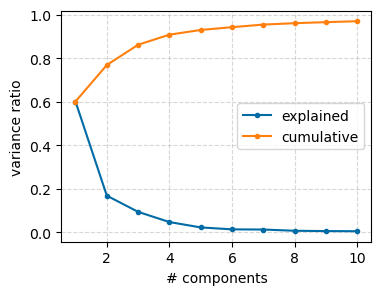

In [186]:
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.linspace(1,10,10),pca.explained_variance_ratio_[0:10],'.-',label='explained')
plt.plot(np.linspace(1,10,10),cumulative_variance_ratio[0:10],'.-',label='cumulative')
plt.grid(ls='--',alpha=0.5)
plt.xlabel('# components')
plt.ylabel('variance ratio')
plt.legend()

In [187]:
pca_5=pca_xyz[:,:5]

In [188]:
mat_pca=sp.spatial.distance_matrix(pca_5,pca_5)

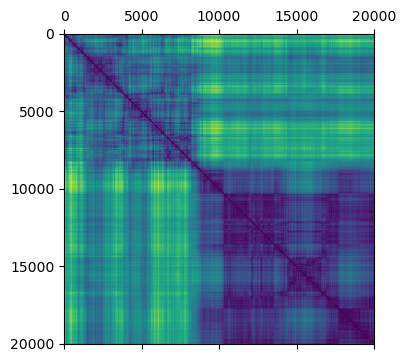

In [420]:
plt.matshow(mat_pca)

### low rg matrix

In [189]:
frame_rg_b_int=np.where(colv_rew[:,5]<2.47)[0]

In [190]:
pca_5.shape

(20001, 5)

In [191]:
points_rg_b=pca_5[frame_rg_b_int]
points_rg_b.shape

(11871, 5)

In [192]:
mat_pca_rg_b=sp.spatial.distance_matrix(points_rg_b,points_rg_b)

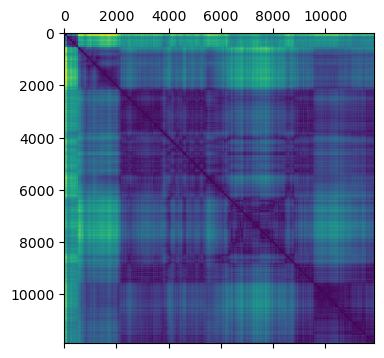

In [132]:
plt.matshow(mat_pca_rg_b)

### high rg matrix

In [193]:
frame_rg_a_int=np.where(colv_rew[:,5]>2.47)[0]

In [194]:
points_rg_a=pca_5[frame_rg_a_int]
points_rg_a.shape

(8130, 5)

In [195]:
mat_pca_rg_a=sp.spatial.distance_matrix(points_rg_a,points_rg_a)

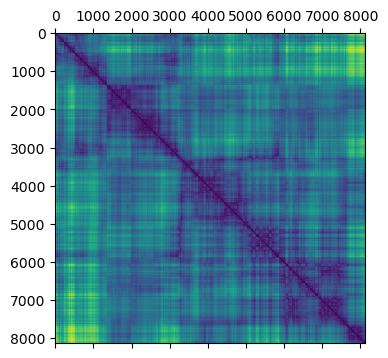

In [136]:
plt.matshow(mat_pca_rg_a)

### QT rg b (compact)

In [196]:
weights_rg_b=w_me[chosen_s][frame_rg_b_int]

In [ ]:
#start=datetime.datetime.now()
#
#cl_qt_cf3_rg_b=clustering.qt(np.array(mat_pca_rg_b,dtype='float32'),weights=weights_rg_b,cutoff=3)
#
#end=datetime.datetime.now()
#tdelta=end-start
#print("total seconds:",tdelta.total_seconds())

total seconds: 34333.549443


In [ ]:
#pickle.dump(cl_qt_cf3_rg_b,open(path_out+"/out_cluster_analysis/clQT_allfr_cf3_s0-03_rg_b.dat", "wb"))

In [197]:
cl_qt_cf3_rg_b=pickle.load(open(path_out+"/out_cluster_analysis/clQT_allfr_cf3_s0-03_rg_b.dat", "rb"))

In [198]:
np.sum(cl_qt_cf3_rg_b.weights)

np.float64(0.35311153116147076)

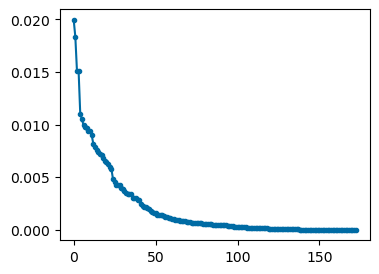

In [199]:
plt.plot(cl_qt_cf3_rg_b.weights,'.-')
plt.show()

In [200]:
cl_qt_cf3_outb={}
for i in range(len(cl_qt_cf3_rg_b.clusters)):
    cl_qt_cf3_outb[i,'lbl']=np.array(cl_qt_cf3_rg_b.clusters[i])
    cl_qt_cf3_outb[i,'size']=len(cl_qt_cf3_rg_b.clusters[i])
    cl_qt_cf3_outb[i,'weight']=cl_qt_cf3_rg_b.weights[i]

In [201]:
sizes_b=[]
weights_b=[]
for i in range(len(cl_qt_cf3_rg_b.clusters)):
    sizes_b.append(cl_qt_cf3_outb[i,'size'])
    weights_b.append(cl_qt_cf3_outb[i,'weight'])
sizes_b=np.array(sizes_b)
weights_b=np.array(weights_b)

In [ ]:
## find centroids, taken from: https://mdtraj.org/1.9.3/examples/centroids.html
## ADAPTED with weights (mbernett)
#centroids=[]
#for i in range(50):
#    cl=cl_qt_cf3_outb[i,'lbl'] # get cluster elements
#    dists_i=mat_pca_rg_b[cl][:,cl] # subselect (from the full original mat) distance matrix for the cluster elements
#    #
#    beta = 1
#    index = np.argmax(np.sum(np.exp(-beta*dists_i / dists_i.std())*weights_rg_b[cl],axis=1)) # index of centroid in the subselected mat
#    centroids.append(cl[index]) # index of centroid in the original array
#centroids_b=np.array(centroids)

In [ ]:
## weighted average Rg of the clusters
#cl_rgs_mb=[]
#for i in range(50):
#    cl_rgs_mb.append(np.average(colv_rew[frame_rg_b_int,5][cl_qt_cf3_outb[i,'lbl']],weights=weights_rg_b[cl_qt_cf3_outb[i,'lbl']])) # (should be) fixed

In [441]:
for i in range(15):
    print('cluster ID:',i,\
          'N_structures:',cl_qt_cf3_outb[i,'size'],\
          'Cluster_weight:',cl_qt_cf3_outb[i,'weight'],\
          'Weighted_Rg_of_cluster:',np.average(colv_rew[frame_rg_b_int,5][cl_qt_cf3_outb[i,'lbl']],weights=weights_rg_b[cl_qt_cf3_outb[i,'lbl']]))

cluster ID: 0 N_structures: 268 Cluster_weight: 0.019960123484015522 Weighted_Rg_of_cluster: 2.347976011821908
cluster ID: 1 N_structures: 264 Cluster_weight: 0.018337833713272883 Weighted_Rg_of_cluster: 2.326136534871516
cluster ID: 2 N_structures: 153 Cluster_weight: 0.015097349722461661 Weighted_Rg_of_cluster: 2.3395274617214397
cluster ID: 3 N_structures: 192 Cluster_weight: 0.015082386766747686 Weighted_Rg_of_cluster: 2.3620165817617504
cluster ID: 4 N_structures: 336 Cluster_weight: 0.0110391375470313 Weighted_Rg_of_cluster: 2.315879267541321
cluster ID: 5 N_structures: 176 Cluster_weight: 0.010531670342132385 Weighted_Rg_of_cluster: 2.333998323751594
cluster ID: 6 N_structures: 92 Cluster_weight: 0.009943008056979518 Weighted_Rg_of_cluster: 2.362237392073302
cluster ID: 7 N_structures: 183 Cluster_weight: 0.0098062690274313 Weighted_Rg_of_cluster: 2.3154879224837637
cluster ID: 8 N_structures: 112 Cluster_weight: 0.009645893388785944 Weighted_Rg_of_cluster: 2.3420511542743125
cl

In [225]:
# For table S1
#for i in range(15):
    #print(i+1)
    #print(f"{cl_qt_cf3_outb[i,'weight']:.5f}")
    #print(f"{np.average(colv_rew[frame_rg_b_int,5][cl_qt_cf3_outb[i,'lbl']],weights=weights_rg_b[cl_qt_cf3_outb[i,'lbl']])*10:.1f}")

### QT rg a (extended)

In [216]:
weights_rg_a=w_me[chosen_s][frame_rg_a_int]

In [ ]:
#start=datetime.datetime.now()
#
#cl_qt_cf3_rg_a=clustering.qt(np.array(mat_pca_rg_a,dtype='float32'),weights=weights_rg_a,cutoff=3)
#
#end=datetime.datetime.now()
#tdelta=end-start
#print("total seconds:",tdelta.total_seconds())

total seconds: 3269.148135


In [ ]:
#pickle.dump(cl_qt_cf3_rg_a,open(path_out+"/out_cluster_analysis/clQT_allfr_cf3_s0-03_rg_a.dat", "wb"))

In [217]:
cl_qt_cf3_rg_a=pickle.load(open(path_out+"/out_cluster_analysis/clQT_allfr_cf3_s0-03_rg_a.dat", "rb"))

In [218]:
np.sum(cl_qt_cf3_rg_a.weights)

np.float64(0.6468884688385295)

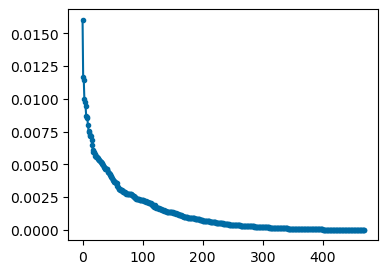

In [219]:
plt.plot(cl_qt_cf3_rg_a.weights,'.-')
plt.show()

In [220]:
cl_qt_cf3_outa={}
for i in range(len(cl_qt_cf3_rg_a.clusters)):
    cl_qt_cf3_outa[i,'lbl']=np.array(cl_qt_cf3_rg_a.clusters[i])
    cl_qt_cf3_outa[i,'size']=len(cl_qt_cf3_rg_a.clusters[i])
    cl_qt_cf3_outa[i,'weight']=cl_qt_cf3_rg_a.weights[i]

In [221]:
sizes_a=[]
weights_a=[]
for i in range(len(cl_qt_cf3_rg_a.clusters)):
    sizes_a.append(cl_qt_cf3_outa[i,'size'])
    weights_a.append(cl_qt_cf3_outa[i,'weight'])
sizes_a=np.array(sizes_a)
weights_a=np.array(weights_a)

In [ ]:
## find centroids, taken from: https://mdtraj.org/1.9.3/examples/centroids.html
## ADAPTED with weights (mbernett)
#centroids=[]
#for i in range(50):
#    cl=cl_qt_cf3_outa[i,'lbl'] # get cluster elements
#    dists_i=mat_pca_rg_a[cl][:,cl] # subselect (from the full original mat) distance matrix for the cluster elements
#    #
#    beta = 1
#    index = np.argmax(np.sum(np.exp(-beta*dists_i / dists_i.std())*weights_rg_a[cl],axis=1)) # index of centroid in the subselected mat
#    centroids.append(cl[index]) # index of centroid in the original array
#centroids=np.array(centroids)

In [ ]:
## weighted average Rg of the clusters
#cl_rgs_mb=[]
#for i in range(50):
#    cl_rgs_mb.append(np.average(colv_rew[frame_rg_a_int,5][cl_qt_cf3_outa[i,'lbl']],weights=weights_rg_a[cl_qt_cf3_outa[i,'lbl']])) # (should be) fixed

In [442]:
for i in range(15):
    print('cluster ID:',i,\
          'N_structures:',cl_qt_cf3_outa[i,'size'],\
          'Cluster_weight:',cl_qt_cf3_outa[i,'weight'],\
          'Weighted_Rg_of_cluster:',np.average(colv_rew[frame_rg_a_int,5][cl_qt_cf3_outa[i,'lbl']],weights=weights_rg_a[cl_qt_cf3_outa[i,'lbl']]))

cluster ID: 0 N_structures: 42 Cluster_weight: 0.016046145005942987 Weighted_Rg_of_cluster: 2.9303043840786964
cluster ID: 1 N_structures: 50 Cluster_weight: 0.011688169970479211 Weighted_Rg_of_cluster: 2.924371186644656
cluster ID: 2 N_structures: 38 Cluster_weight: 0.011479257925698467 Weighted_Rg_of_cluster: 2.933534151814239
cluster ID: 3 N_structures: 65 Cluster_weight: 0.009987861162316725 Weighted_Rg_of_cluster: 2.6777108114860644
cluster ID: 4 N_structures: 53 Cluster_weight: 0.009747022843969397 Weighted_Rg_of_cluster: 2.7108104584531305
cluster ID: 5 N_structures: 43 Cluster_weight: 0.009457586718015365 Weighted_Rg_of_cluster: 2.9287336857000317
cluster ID: 6 N_structures: 62 Cluster_weight: 0.008696616223893146 Weighted_Rg_of_cluster: 2.777363088365355
cluster ID: 7 N_structures: 50 Cluster_weight: 0.008605879251098054 Weighted_Rg_of_cluster: 2.86875147249665
cluster ID: 8 N_structures: 36 Cluster_weight: 0.008520035788315644 Weighted_Rg_of_cluster: 2.9335317951749187
cluste

In [224]:
# For table S1
#for i in range(15):
    #print(i+1)
    #print(f"{cl_qt_cf3_outa[i,'weight']:.5f}")
    #print(f"{np.average(colv_rew[frame_rg_a_int,5][cl_qt_cf3_outa[i,'lbl']],weights=weights_rg_a[cl_qt_cf3_outa[i,'lbl']])*10:.1f}")

#### Extract centroids

### 

In [444]:
# get centroids for rg_a group in the overall matrix mat_pca
# find centroids, taken from: https://mdtraj.org/1.9.3/examples/centroids.html
# ADAPTED with weights (mbernett)
centroids_a=[]
for i in range(len(cl_qt_cf3_rg_a.clusters)):
    cl=cl_qt_cf3_outa[i,'lbl'] # get cluster elements
    dists_i=mat_pca_rg_a[cl][:,cl] # subselect (from the full original mat) distance matrix for the cluster elements
    #
    beta = 1
    index = np.argmax(np.sum(np.exp(-beta*dists_i / dists_i.std())*weights_rg_a[cl],axis=1)) # index of centroid in the subselected mat
    centroids_a.append(cl[index]) # index of centroid in the original array
centroids_a=np.array(centroids_a)

/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_16013/1442363354.py:10: RuntimeWarning: invalid value encountered in divide
  index = np.argmax(np.sum(np.exp(-beta*dists_i / dists_i.std())*weights_rg_a[cl],axis=1)) # index of centroid in the subselected mat


In [ ]:
traj[frame_rg_a_int[centroids_a]].save(path_out+'/out_cluster_analysis/centroids_qt_cf3_rga_extended.xtc')

In [ ]:
#for i in range(len(centroids_a)):
for i in range(15): # first N clusters
    traj[frame_rg_a_int[centroids_a[i]]].save(path_out+'/out_cluster_analysis/centroid_%s_qt_cf3_rga_extended.pdb'%i)

    # Read the file back, modify the first REMARK line
    fname=path_out+'/out_cluster_analysis/centroid_%s_qt_cf3_rga_extended.pdb'%i
    with open(fname, "r") as f:
        lines = f.readlines()

    if lines and lines[0].startswith("REMARK   1"):
        lines[0] = f"REMARK   1 Cluster weight: {cl_qt_cf3_outa[i,'weight']:.5f}, CREATED WITH MDTraj {mdt.__version__}, {str(datetime.date.today())}\n"

    # Write modified file
    with open(fname, "w") as f:
        f.writelines(lines)

In [463]:
# get centroids for rg_a group in the overall matrix mat_pca
# find centroids, taken from: https://mdtraj.org/1.9.3/examples/centroids.html
# ADAPTED with weights (mbernett)
centroids_b=[]
for i in range(len(cl_qt_cf3_rg_b.clusters)):
    cl=cl_qt_cf3_outb[i,'lbl'] # get cluster elements
    dists_i=mat_pca_rg_b[cl][:,cl] # subselect (from the full original mat) distance matrix for the cluster elements
    #
    beta = 1
    index = np.argmax(np.sum(np.exp(-beta*dists_i / dists_i.std())*weights_rg_b[cl],axis=1)) # index of centroid in the subselected mat
    centroids_b.append(cl[index]) # index of centroid in the original array
centroids_b=np.array(centroids_b)

/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_16013/1634802283.py:10: RuntimeWarning: invalid value encountered in divide
  index = np.argmax(np.sum(np.exp(-beta*dists_i / dists_i.std())*weights_rg_b[cl],axis=1)) # index of centroid in the subselected mat


In [ ]:
traj[frame_rg_b_int[centroids_b]].save(path_out+'/out_cluster_analysis/centroids_qt_cf3_rgb_compact.xtc')

In [ ]:
#for i in range(len(centroids_b)):
for i in range(15): # first N clusters
    traj[frame_rg_b_int[centroids_b[i]]].save(path_out+'/out_cluster_analysis/centroid_%s_qt_cf3_rgb_compact.pdb'%i)

    # Read the file back, modify the first REMARK line
    fname=path_out+'/out_cluster_analysis/centroid_%s_qt_cf3_rgb_compact.pdb'%i
    with open(fname, "r") as f:
        lines = f.readlines()

    if lines and lines[0].startswith("REMARK   1"):
        lines[0] = f"REMARK   1 Cluster weight: {cl_qt_cf3_outb[i,'weight']:.5f}, CREATED WITH MDTraj {mdt.__version__}, {str(datetime.date.today())}\n"

    # Write modified file
    with open(fname, "w") as f:
        f.writelines(lines)

#### Extract entire ensemble

In [ ]:
w_me[chosen_s].shape,traj

((20001,),
 <mdtraj.Trajectory with 20001 frames, 5829 atoms, 379 residues, and unitcells at 0x17d236490>)

In [ ]:
np.min(w_me[chosen_s]),np.max(w_me[chosen_s])

(np.float64(1.7476044949300495e-25), np.float64(0.0006294449472738338))

In [ ]:
for i in range(traj.n_frames): 
    traj[i].save(path_out+'/reweighted_ensemble_pdb/frame_%s.pdb'%i)

    # Read the file back, modify the first REMARK line
    fname=path_out+'/reweighted_ensemble_pdb/frame_%s.pdb'%i
    with open(fname, "r") as f:
        lines = f.readlines()

    if lines and lines[0].startswith("REMARK   1"):
        lines[0] = f"REMARK   1 Weight: {w_me[chosen_s][i]:.5g}, CREATED WITH MDTraj {mdt.__version__}, {str(datetime.date.today())}\n"

    # Write modified file
    with open(fname, "w") as f:
        f.writelines(lines)

#### Make histograms of the XL-MS distances for different clusters

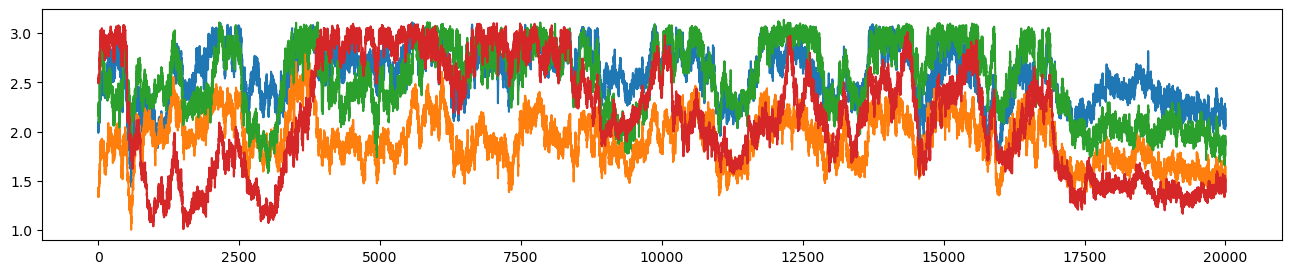

In [ ]:
plt.figure(figsize=(16, 3))
plt.plot(colv_rew[:,1],color='tab:blue')
plt.plot(colv_rew[:,2],color='tab:orange')
plt.plot(colv_rew[:,3],color='tab:green')
plt.plot(colv_rew[:,4],color='tab:red')
plt.show()

In [ ]:
## Just checks
#colv_rew[frame_rg_a_int,1:5][cl_qt_cf3_outa[i,'lbl']].shape,w_me[chosen_s][frame_rg_a_int][cl_qt_cf3_outa[i,'lbl']].shape
## step 1: per frame average over the 4 distances
#per_frame_avg = colv_rew[frame_rg_a_int,1:5][cl_qt_cf3_outa[i,'lbl']].mean(axis=1) * 10  # shape (42,)
## step 2: weighted average over alla frames contained in the cluster
#weighted_avg = np.average(per_frame_avg, weights=w_me[chosen_s][frame_rg_a_int][cl_qt_cf3_outa[i,'lbl']])

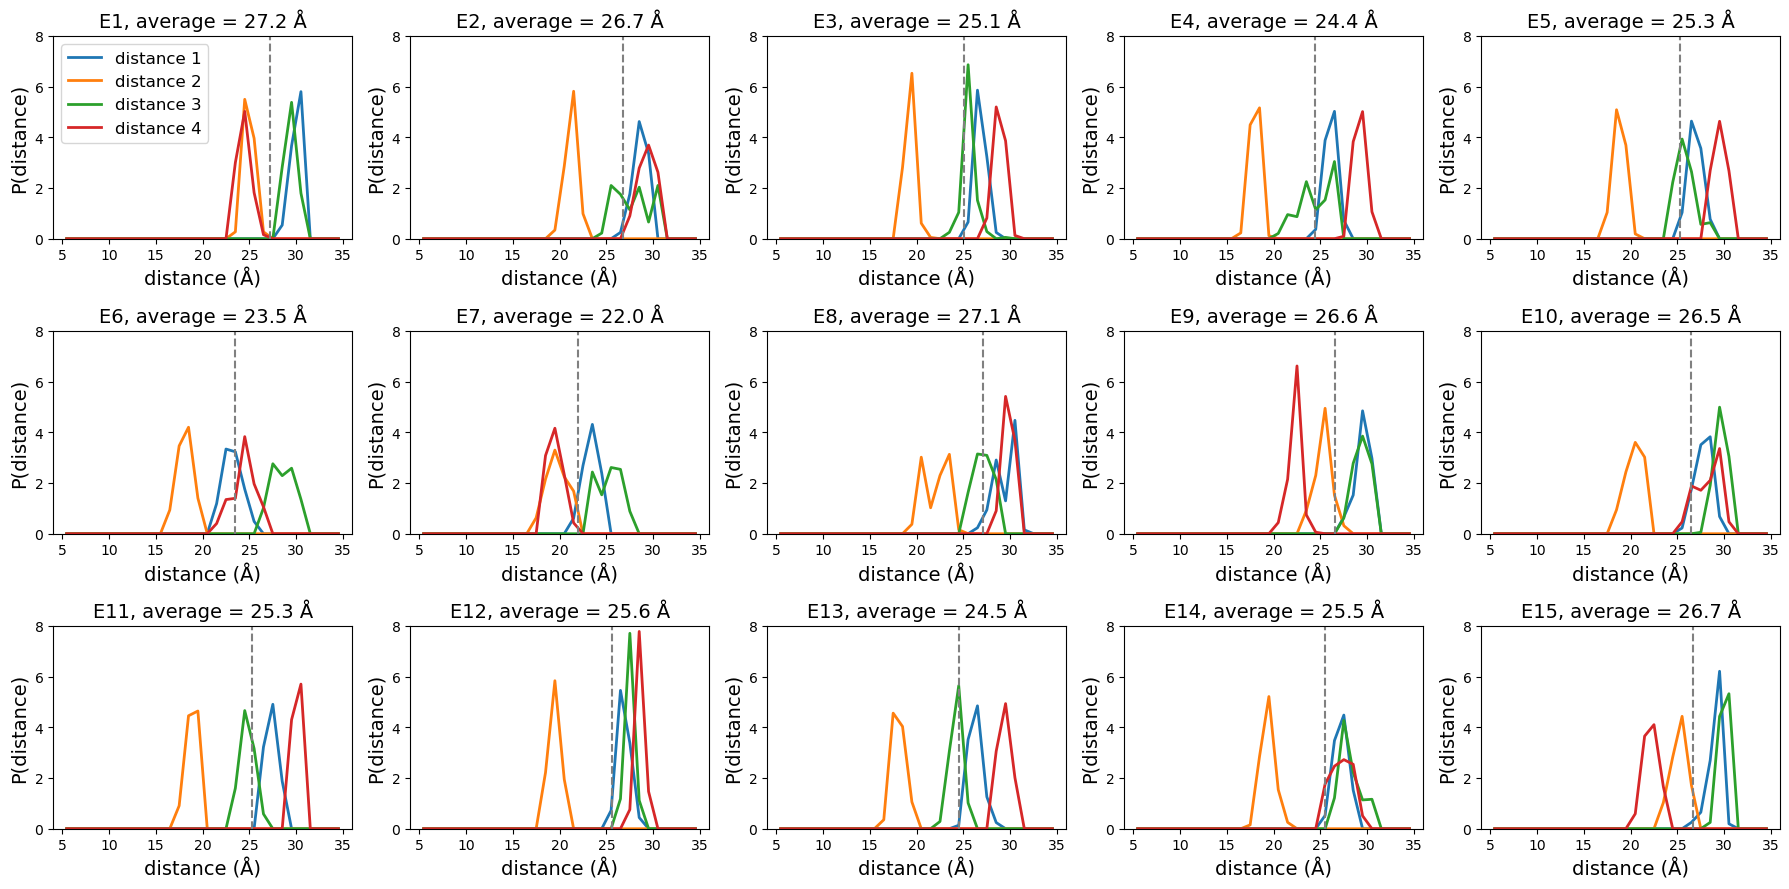

In [ ]:
plt.figure(figsize=(18,9))
for i in range(15):
    plt.subplot(3,5,i+1)
    histd_1=np.histogram(colv_rew[frame_rg_a_int,1][cl_qt_cf3_outa[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_a_int][cl_qt_cf3_outa[i,'lbl']],density=True)
    histd_2=np.histogram(colv_rew[frame_rg_a_int,2][cl_qt_cf3_outa[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_a_int][cl_qt_cf3_outa[i,'lbl']],density=True)
    histd_3=np.histogram(colv_rew[frame_rg_a_int,3][cl_qt_cf3_outa[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_a_int][cl_qt_cf3_outa[i,'lbl']],density=True)
    histd_4=np.histogram(colv_rew[frame_rg_a_int,4][cl_qt_cf3_outa[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_a_int][cl_qt_cf3_outa[i,'lbl']],density=True)
    plt.plot((histd_1[1][:-1]+histd_1[1][1:])/2*10,histd_1[0],lw=2,color='tab:blue',label='distance 1')
    plt.plot((histd_2[1][:-1]+histd_2[1][1:])/2*10,histd_2[0],lw=2,color='tab:orange',label='distance 2')
    plt.plot((histd_3[1][:-1]+histd_3[1][1:])/2*10,histd_3[0],lw=2,color='tab:green',label='distance 3')
    plt.plot((histd_4[1][:-1]+histd_4[1][1:])/2*10,histd_4[0],lw=2,color='tab:red',label='distance 4')
    #
    # step 1: per frame average over the 4 distances
    per_frame_avg = colv_rew[frame_rg_a_int,1:5][cl_qt_cf3_outa[i,'lbl']].mean(axis=1) * 10 
    # step 2: weighted average over all frames contained in the cluster
    weighted_avg = np.average(per_frame_avg, weights=w_me[chosen_s][frame_rg_a_int][cl_qt_cf3_outa[i,'lbl']])
    plt.vlines(weighted_avg,0,8,ls='--',color='grey')
    #
    plt.ylim(0,8)
    plt.xlabel('distance (Å)',fontsize=14)
    plt.ylabel('P(distance)',fontsize=14)
    plt.title(f'E{i+1}, average = {weighted_avg:.1f} Å',fontsize=14)
    if i == 0:
        plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
#plt.savefig(path_out+'histo_distances_extended.png',dpi=300,bbox_inches='tight')

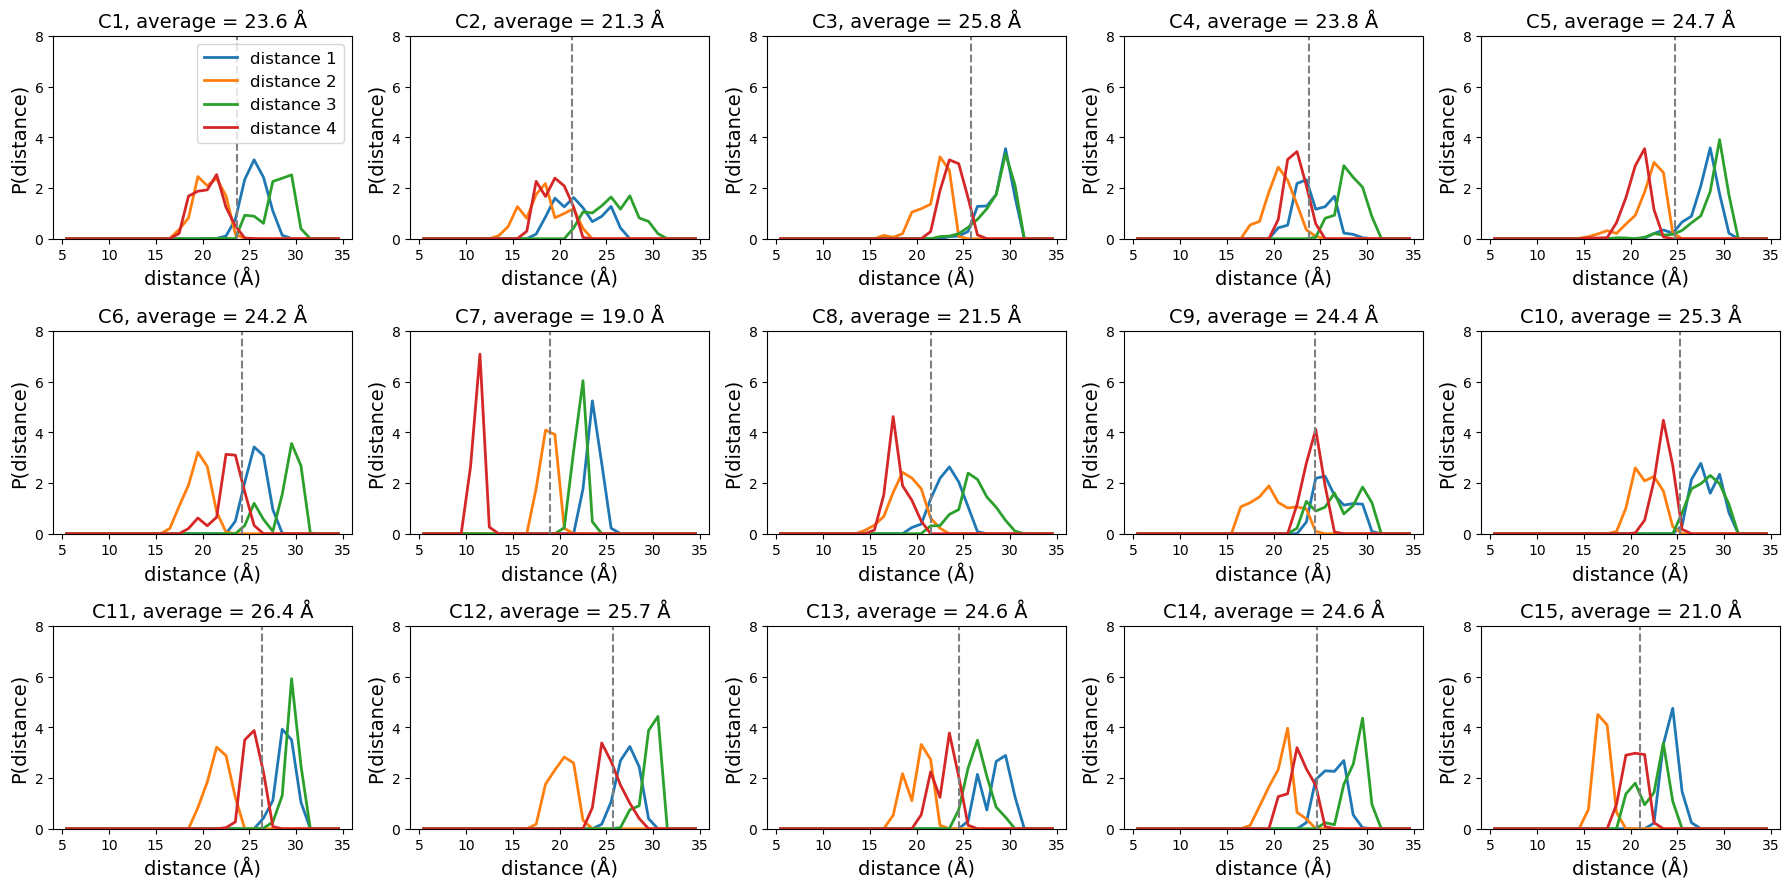

In [ ]:
plt.figure(figsize=(18,9))
for i in range(15):
    plt.subplot(3,5,i+1)
    histd_1=np.histogram(colv_rew[frame_rg_b_int,1][cl_qt_cf3_outb[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_b_int][cl_qt_cf3_outb[i,'lbl']],density=True)
    histd_2=np.histogram(colv_rew[frame_rg_b_int,2][cl_qt_cf3_outb[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_b_int][cl_qt_cf3_outb[i,'lbl']],density=True)
    histd_3=np.histogram(colv_rew[frame_rg_b_int,3][cl_qt_cf3_outb[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_b_int][cl_qt_cf3_outb[i,'lbl']],density=True)
    histd_4=np.histogram(colv_rew[frame_rg_b_int,4][cl_qt_cf3_outb[i,'lbl']],bins=30,range=(0.5,3.5),weights=w_me[chosen_s][frame_rg_b_int][cl_qt_cf3_outb[i,'lbl']],density=True)
    plt.plot((histd_1[1][:-1]+histd_1[1][1:])/2*10,histd_1[0],lw=2,color='tab:blue',label='distance 1')
    plt.plot((histd_2[1][:-1]+histd_2[1][1:])/2*10,histd_2[0],lw=2,color='tab:orange',label='distance 2')
    plt.plot((histd_3[1][:-1]+histd_3[1][1:])/2*10,histd_3[0],lw=2,color='tab:green',label='distance 3')
    plt.plot((histd_4[1][:-1]+histd_4[1][1:])/2*10,histd_4[0],lw=2,color='tab:red',label='distance 4')
    #
    # step 1: per frame average over the 4 distances
    per_frame_avg = colv_rew[frame_rg_b_int,1:5][cl_qt_cf3_outb[i,'lbl']].mean(axis=1) * 10 
    # step 2: weighted average over all frames contained in the cluster
    weighted_avg = np.average(per_frame_avg, weights=w_me[chosen_s][frame_rg_b_int][cl_qt_cf3_outb[i,'lbl']])
    plt.vlines(weighted_avg,0,8,ls='--',color='grey')
    #
    plt.ylim(0,8)    
    plt.xlabel('distance (Å)',fontsize=14)
    plt.ylabel('P(distance)',fontsize=14)
    plt.title(f'C{i+1}, average = {weighted_avg:.1f} Å',fontsize=14)
    if i == 0:
        plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
#plt.savefig(path_out+'histo_distances_compact.png',dpi=300,bbox_inches='tight')

In [160]:
cen_b=points_rg_b[centroids_b]

In [161]:
cen_a=points_rg_a[centroids_a]

In [162]:
cat_new=np.concatenate((cen_a,cen_b))

In [163]:
pickle.dump(cat_new,open(path_out+'concat_cen_a_b', "wb"))

In [164]:
cat_new=pickle.load(open(path_out+"concat_cen_a_b", "rb"))

In [165]:
mat_cen=sp.spatial.distance_matrix(cat_new,cat_new)

In [166]:
pickle.dump(mat_cen,open(path_out+'mat_centroidi_rg_a_b', "wb"))

In [167]:
mat_cen=pickle.load(open(path_out+"mat_centroidi_rg_a_b", "rb"))

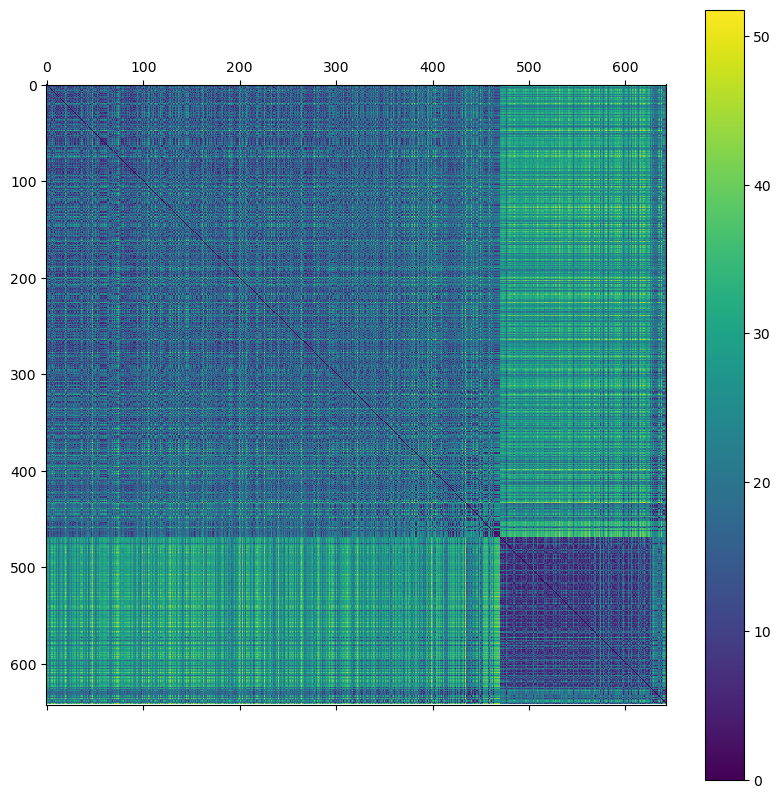

In [168]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
cax = ax.matshow(mat_cen, interpolation='nearest')
fig.colorbar(cax)

In [169]:
weights_a_b=cl_qt_cf3_rg_a.weights+cl_qt_cf3_rg_b.weights

In [170]:
weights_a_b_np=np.array(weights_a_b)

In [171]:
weights_a_b_norm=(weights_a_b_np-np.min(weights_a_b_np))/(np.max(weights_a_b_np)-np.min(weights_a_b_np))

In [172]:
weights_norm_sigm=250/(1+np.exp(-15*(weights_a_b_norm-0.5)))+1

In [173]:
color_a=[]
for cl in range(len(cl_qt_cf3_rg_a.clusters)):
    color_a.append('#8ecff5')

In [174]:
color_b=[]
for cl in range(len(cl_qt_cf3_rg_b.clusters)):
    color_b.append('#f5c18e')

In [175]:
g=net.Network(notebook=True, cdn_resources='remote')
label_a=[]
label_b=[]
for el in (range(len(cl_qt_cf3_rg_a.weights))):
    label_a.append('a'+str(el))
for el in (range(len(cl_qt_cf3_rg_b.weights))):
    label_b.append('b'+str(el))
    
g.add_nodes(range(len(cl_qt_cf3_rg_a.weights)), size=weights_norm_sigm[0:470],
                         color=color_a, label=label_a)
g.add_nodes(range(len(cl_qt_cf3_rg_a.weights),len(cl_qt_cf3_rg_a.weights)+len(cl_qt_cf3_rg_b.weights)), size=weights_norm_sigm[470:len(weights_norm_sigm)],
                         color=color_b, label=label_b)
for i in range(len(cat_new)):
    for j in range(len(cat_new)):
        if mat_cen[i,j]>5:
            pass
        else:
            if i==j:
                pass
            else:
                g.add_edge(i,j, width=1)
g.set_edge_smooth('dynamic')

g.barnes_hut(gravity=-2000, central_gravity=0.3, spring_length=95, spring_strength=0.03, damping=0.09, overlap=0)

g.show_buttons(filter_=['physics'])

g.save_graph(path_out+"network.html")

### Compute RMSD matrix between steered MD final structures and AF model

In [87]:
af_model_renum=MDAnalysis.Universe(path+'/relaxed_model_AF.pdb',path+'/relaxed_model_AF.pdb')

In [88]:
onebead1=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_o1_stride5.xtc')
onebead2=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_o2_stride5.xtc')
onebead3=MDAnalysis.Universe(path+'protein_renum.pdb',path+'fixtraj_protein_o3_stride5.xtc')

In [89]:
bead1.select_atoms("resid 341 to 379")

<AtomGroup with 641 atoms>

In [90]:
af_model_renum.select_atoms("chainID A").residues.resids=bead1.select_atoms("resid 341 to 379").residues.resids

In [91]:
R = rms.RMSD(af_model_renum,  # universe to align
             af_model_renum,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=0)  # frame index of the reference
R.run()
R.results

/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/Users/mbernetti/my_progs/miniconda3/lib/python3.13/site-packages/MDAnalysis/coordinates/base.py:757: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.time


{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 4.91452504e-07, 3.75957686e-07]])}

In [92]:
R1 = rms.RMSD(bead1,  # universe to align
             af_model_renum,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=0)  # frame index of the reference
R1.run()
R1.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 5.44172354e-01, 3.07647534e+01],
       [1.00000000e+00, 2.50000000e+01, 7.84276357e-01, 3.07840774e+01],
       [2.00000000e+00, 5.00000000e+01, 9.22147886e-01, 3.08853715e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 1.52713273e+00, 3.38925406e+01],
       [3.99000000e+02, 9.97500000e+03, 1.44079536e+00, 3.36446978e+01],
       [4.00000000e+02, 1.00000000e+04, 1.46030703e+00, 3.35744208e+01]],
      shape=(401, 4))}

In [93]:
R2 = rms.RMSD(bead2,  # universe to align
             af_model_renum,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=0)  # frame index of the reference
R2.run()
R2.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 5.44172354e-01, 3.07647534e+01],
       [1.00000000e+00, 2.50000000e+01, 7.51848426e-01, 3.08207447e+01],
       [2.00000000e+00, 5.00000000e+01, 9.46087686e-01, 3.08724865e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 1.71750344e+00, 3.36202331e+01],
       [3.99000000e+02, 9.97500000e+03, 1.76440514e+00, 3.36052558e+01],
       [4.00000000e+02, 1.00000000e+04, 1.87902345e+00, 3.36903736e+01]],
      shape=(401, 4))}

In [94]:
R3 = rms.RMSD(bead3,  # universe to align
             af_model_renum,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=0)  # frame index of the reference
R3.run()
R3.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 5.44172354e-01, 3.07647534e+01],
       [1.00000000e+00, 2.50000000e+01, 7.61635222e-01, 3.07776153e+01],
       [2.00000000e+00, 5.00000000e+01, 7.76025706e-01, 3.08573701e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 2.30596589e+00, 3.26404219e+01],
       [3.99000000e+02, 9.97500000e+03, 2.28944928e+00, 3.25671829e+01],
       [4.00000000e+02, 1.00000000e+04, 2.46706830e+00, 3.26013843e+01]],
      shape=(401, 4))}

In [95]:
R_10 = rms.RMSD(af_model_renum,  # universe to align
             bead1,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_10.run()
R_10.results

{'rmsd': array([[ 0.        ,  0.        ,  1.46030703, 33.57442057]])}

In [96]:
R_11 = rms.RMSD(bead1,  # universe to align
             bead1,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_11.run()
R_11.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 1.46014132e+00, 1.85459856e+01],
       [1.00000000e+00, 2.50000000e+01, 1.40240147e+00, 1.86605367e+01],
       [2.00000000e+00, 5.00000000e+01, 1.60886970e+00, 1.88280749e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 7.63876151e-01, 2.47253711e+00],
       [3.99000000e+02, 9.97500000e+03, 6.28059306e-01, 1.23505428e+00],
       [4.00000000e+02, 1.00000000e+04, 0.00000000e+00, 8.48479022e-08]],
      shape=(401, 4))}

In [97]:
R_12 = rms.RMSD(bead2,  # universe to align
             bead1,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_12.run()
R_12.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 1.46014132e+00, 1.85459856e+01],
       [1.00000000e+00, 2.50000000e+01, 1.47790860e+00, 1.85033912e+01],
       [2.00000000e+00, 5.00000000e+01, 1.52948669e+00, 1.84965191e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 2.01528245e+00, 5.69397941e+00],
       [3.99000000e+02, 9.97500000e+03, 2.03919433e+00, 4.86390885e+00],
       [4.00000000e+02, 1.00000000e+04, 2.21095319e+00, 5.58165567e+00]],
      shape=(401, 4))}

In [98]:
R_13 = rms.RMSD(bead3,  # universe to align
             bead1,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_13.run()
R_13.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 1.46014132e+00, 1.85459856e+01],
       [1.00000000e+00, 2.50000000e+01, 1.50101858e+00, 1.84039147e+01],
       [2.00000000e+00, 5.00000000e+01, 1.46956818e+00, 1.85431515e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 2.66710765e+00, 9.39875763e+00],
       [3.99000000e+02, 9.97500000e+03, 2.64534049e+00, 9.50603175e+00],
       [4.00000000e+02, 1.00000000e+04, 2.82791303e+00, 9.48253323e+00]],
      shape=(401, 4))}

In [99]:
R_20 = rms.RMSD(af_model_renum,  # universe to align
             bead2,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_20.run()
R_20.results

{'rmsd': array([[ 0.        ,  0.        ,  1.87902345, 33.6903736 ]])}

In [100]:
R_21 = rms.RMSD(bead1,  # universe to align
             bead2,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_21.run()
R_21.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 1.82966453e+00, 2.09144074e+01],
       [1.00000000e+00, 2.50000000e+01, 1.97567598e+00, 2.10550380e+01],
       [2.00000000e+00, 5.00000000e+01, 1.93370019e+00, 2.11916705e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 2.37379012e+00, 5.52235767e+00],
       [3.99000000e+02, 9.97500000e+03, 2.25239224e+00, 6.03551957e+00],
       [4.00000000e+02, 1.00000000e+04, 2.21095319e+00, 5.58165574e+00]],
      shape=(401, 4))}

In [101]:
R_22 = rms.RMSD(bead2,  # universe to align
             bead2,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_22.run()
R_22.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 1.82966453e+00, 2.09144074e+01],
       [1.00000000e+00, 2.50000000e+01, 1.80697462e+00, 2.08423468e+01],
       [2.00000000e+00, 5.00000000e+01, 1.78542132e+00, 2.08110043e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 7.77927689e-01, 1.43190655e+00],
       [3.99000000e+02, 9.97500000e+03, 6.94638882e-01, 1.28068056e+00],
       [4.00000000e+02, 1.00000000e+04, 3.47509398e-07, 1.38556044e-07]],
      shape=(401, 4))}

In [102]:
R_23 = rms.RMSD(bead3,  # universe to align
             bead2,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_23.run()
R_23.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 1.82966453e+00, 2.09144074e+01],
       [1.00000000e+00, 2.50000000e+01, 2.00228293e+00, 2.07692243e+01],
       [2.00000000e+00, 5.00000000e+01, 1.84665292e+00, 2.08688255e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 1.62906574e+00, 1.27219840e+01],
       [3.99000000e+02, 9.97500000e+03, 1.62810907e+00, 1.28458933e+01],
       [4.00000000e+02, 1.00000000e+04, 1.66660894e+00, 1.28637683e+01]],
      shape=(401, 4))}

In [103]:
R_30 = rms.RMSD(af_model_renum,  # universe to align
             bead3,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_30.run()
R_30.results

{'rmsd': array([[ 0.        ,  0.        ,  2.4670683 , 32.60138474]])}

In [104]:
R_31 = rms.RMSD(bead1,  # universe to align
             bead3,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_31.run()
R_31.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 2.42312334e+00, 1.64924703e+01],
       [1.00000000e+00, 2.50000000e+01, 2.56072508e+00, 1.64499104e+01],
       [2.00000000e+00, 5.00000000e+01, 2.48878204e+00, 1.66692784e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 3.03596777e+00, 1.09479162e+01],
       [3.99000000e+02, 9.97500000e+03, 2.87654085e+00, 9.32104795e+00],
       [4.00000000e+02, 1.00000000e+04, 2.82791303e+00, 9.48253328e+00]],
      shape=(401, 4))}

In [105]:
R_32 = rms.RMSD(bead2,  # universe to align
             bead3,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_32.run()
R_32.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 2.42312334e+00, 1.64924703e+01],
       [1.00000000e+00, 2.50000000e+01, 2.44703722e+00, 1.64986275e+01],
       [2.00000000e+00, 5.00000000e+01, 2.47748491e+00, 1.64324078e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 1.92045602e+00, 1.28320930e+01],
       [3.99000000e+02, 9.97500000e+03, 1.81697860e+00, 1.22022542e+01],
       [4.00000000e+02, 1.00000000e+04, 1.66660894e+00, 1.28637685e+01]],
      shape=(401, 4))}

In [106]:
R_33 = rms.RMSD(bead3,  # universe to align
             bead3,  # reference universe or atomgroup
             select='name CA and (resid 100 to 340)',  # group to superimpose and calculate RMSD
             groupselections=['name CA'],  # groups for RMSD
             ref_frame=-1)  # frame index of the reference
R_33.run()
R_33.results

{'rmsd': array([[0.00000000e+00, 0.00000000e+00, 2.42312334e+00, 1.64924703e+01],
       [1.00000000e+00, 2.50000000e+01, 2.50129590e+00, 1.64265850e+01],
       [2.00000000e+00, 5.00000000e+01, 2.37557578e+00, 1.66648859e+01],
       ...,
       [3.98000000e+02, 9.95000000e+03, 7.06645546e-01, 1.41394523e+00],
       [3.99000000e+02, 9.97500000e+03, 6.46750335e-01, 9.47590550e-01],
       [4.00000000e+02, 1.00000000e+04, 6.01903934e-07, 3.46227702e-07]],
      shape=(401, 4))}

In [107]:
matrix_4_renum=np.empty((4,4))
matrix_4_renum[0,0]=R.results['rmsd'][0][3]
matrix_4_renum[0,1]=R1.results['rmsd'][-1,-1]
matrix_4_renum[0,2]=R2.results['rmsd'][-1,-1]
matrix_4_renum[0,3]=R3.results['rmsd'][-1,-1]
matrix_4_renum[1,0]=R_10.results['rmsd'][0][3]
matrix_4_renum[1,1]=R_11.results['rmsd'][-1,-1]
matrix_4_renum[1,2]=R_12.results['rmsd'][-1,-1]
matrix_4_renum[1,3]=R_13.results['rmsd'][-1,-1]
matrix_4_renum[2,0]=R_20.results['rmsd'][0][3]
matrix_4_renum[2,1]=R_21.results['rmsd'][-1,-1]
matrix_4_renum[2,2]=R_22.results['rmsd'][-1,-1]
matrix_4_renum[2,3]=R_23.results['rmsd'][-1,-1]
matrix_4_renum[3,0]=R_30.results['rmsd'][0][3]
matrix_4_renum[3,1]=R_31.results['rmsd'][-1,-1]
matrix_4_renum[3,2]=R_32.results['rmsd'][-1,-1]
matrix_4_renum[3,3]=R_33.results['rmsd'][-1,-1]

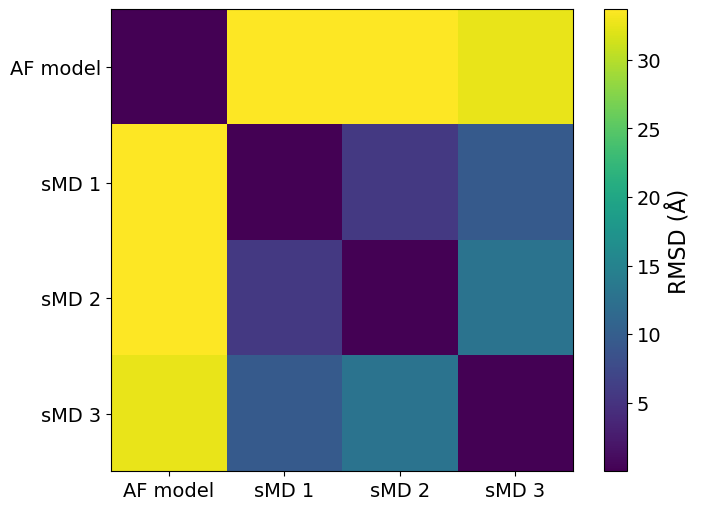

In [ ]:
plt.figure(figsize=(8,6))
#plt.figure(figsize=(1.8,1.8))

plt.imshow(matrix_4_renum, interpolation="nearest")

#plt.colorbar(label='RMSD (Å)')
cbar = plt.colorbar(label='RMSD (Å)')
cbar.ax.tick_params(labelsize=14)   # size of tick labels
cbar.set_label('RMSD (Å)', fontsize=16)  # size of the colorbar label

#plt.title('RMSD matrix')
plt.xticks(ticks=(0,1,2,3),labels=("AF model","sMD 1","sMD 2","sMD 3"))
plt.yticks(ticks=(0,1,2,3),labels=("AF model","sMD 1","sMD 2","sMD 3"))
plt.xticks(fontsize=(14))
plt.yticks(fontsize=(14))
#plt.savefig(path_out+"/matrix_4_smd.png",dpi=1200,bbox_inches="tight")
plt.show

### Reweighting: 10-strided version

In [531]:
colv_rew=np.loadtxt(path+'colvar_metad_restr_bias_100ns')[::10]
colv_rew.shape

(2001, 9)

In [532]:
weights=np.exp((colv_rew[:,-1]-np.max(colv_rew[:,-1]))/2.5) # avoid numeric overflow
weights=weights/np.sum(weights) # normalize

In [533]:
histo=np.histogram(colv_rew[:,5],bins=51,range=(2.0,3.3),weights=weights) 
histo_nw=np.histogram(colv_rew[:,5],bins=51,range=(2.0,3.3)) 

/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3683275987.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo_nw[1][:-1]+histo_nw[1][1:])/2,(-2.5*np.log(histo_nw[0])-np.min(-2.5*np.log(histo_nw[0])))/4.184,label='non weighted')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3683275987.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')


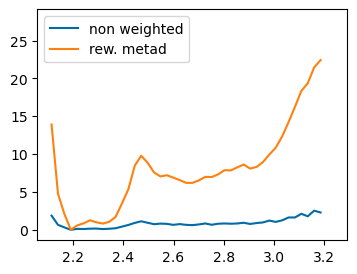

In [534]:
plt.plot((histo_nw[1][:-1]+histo_nw[1][1:])/2,(-2.5*np.log(histo_nw[0])-np.min(-2.5*np.log(histo_nw[0])))/4.184,label='non weighted')
plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')
plt.legend()
plt.show()

In [535]:
spectra_ob=np.loadtxt(path+'colvar_onebead_DRIVER_SolvStride1')[::10]
spectra_ob.shape

(2001, 55)

In [536]:
qs=exp_whole[selected_points,0]
exp=uf_exp_whole[selected_points]
scale_exp=np.exp(intercept)

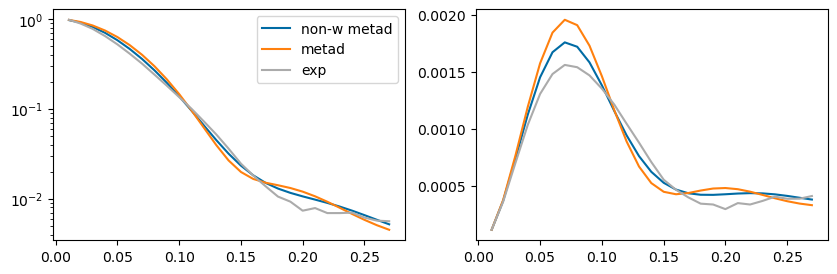

In [537]:
plt.figure(figsize=(10,3))
plt.tight_layout()
plt.subplot(1,2,1)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0),label='non-w metad')
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=weights),label='metad')
plt.plot(qs,exp/scale_exp,label='exp')
plt.yscale('log')
plt.legend()
plt.subplot(1,2,2)
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0))
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=weights))
plt.plot(qs,exp/scale_exp*qs**2,label='exp')
plt.show()

In [538]:
# Maxent function:
def Gamma(l,metadb,observables,e,sigma=0.0):
    l = np.array(l)
    weight_all = metadb / 2.5 # metadb is the array of metadynamics bias associated with each frame (assigned using the total final bias)
    weight_all -= np.dot(observables,l) # lamba*s inside the exponential of the maxent formula
    shift_all = np.max(weight_all) # shift to be subtracted to avoid numerical overflow problems in the exponential
    weight_all = np.exp(weight_all - shift_all)

    weight_mt = metadb / 2.5 
    shift_mt = np.max(weight_mt) # shift to be subtracted to avoid numerical overflow problems in the exponential
    weight_mt = np.exp(weight_mt - shift_mt)

    f = np.log(np.sum(weight_all) / np.sum(weight_mt)) + shift_all - shift_mt + np.dot(l,e)
    der = e - np.dot(weight_all,observables) / np.sum(weight_all) # derivative with respect to l
    reg=sigma**2 # regularization term
    f+=0.5*np.sum(reg*l**2)
    der+=reg*l
    
    return(f,der)

def weights_noprop(l,metadb,observables,e):
    l = np.array(l)
    weight_all = metadb / 2.5
    obs_prop=observables - e
    #print(observables[0],obs_prop[0])

    weight_all -= np.dot(obs_prop,l) # lamba*s inside the exponential of the maxent formula
    shift_all = np.max(weight_all) # shift to be subtracted to avoid numerical overflow problems in the exponential
    weight_all = np.exp(weight_all - shift_all) 

    return weight_all/ np.sum(weight_all)

__Sanity check__ of the maxent function, using the __metad spectrum__ (instead of the exp.)  as target for maxent. This should return the original weights of the metad:

In [539]:
res = minimize(Gamma, np.zeros(qs.shape), method='BFGS',tol=1e-10,jac=True,
           args=(colv_rew[:,-1],spectra_ob[:,1:28],np.average(spectra_ob[:,1:28],axis=0,weights=weights),1e-10)) 

In [540]:
w_me = weights_noprop(res.x,colv_rew[:,-1],spectra_ob[:,1:28],np.average(spectra_ob[:,1:28],axis=0,weights=weights))

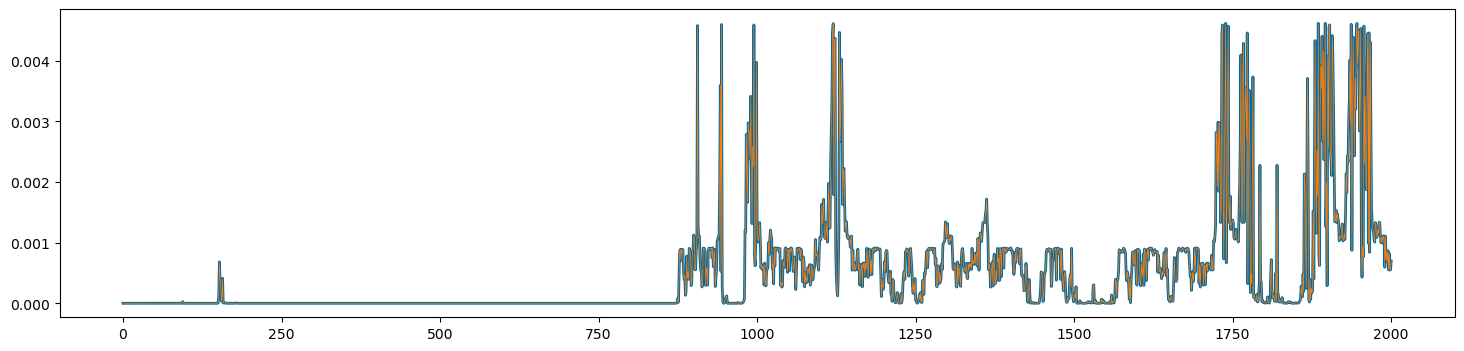

In [541]:
plt.figure(figsize=(18,4))
plt.plot(w_me,lw=2)
plt.plot(weights,lw=0.5)
#plt.xlim(0,2e4)
plt.show()

In [542]:
sigmas=np.array([1e-10,1e-4,4e-4,5e-4,6e-4,8e-4,1e-3,2e-3,3e-3,4e-3,5e-3,1e-2,3e-2,5e-2,1e-1,1,1e1,1e2,1e3])
kishes={}
w_me={}
for i in range(len(sigmas)):
    res_i = minimize(Gamma, np.zeros(qs.shape), method='BFGS',tol=1e-10,jac=True,
                   args=(colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp,sigmas[i]))
    w_me_i = weights_noprop(res_i.x,colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp)
    w_me[sigmas[i]] = w_me_i # w_me.append(w_me_i)
    kish_i = 1 / np.sum(w_me_i**2)
    kishes[sigmas[i]] = kish_i # kishes.append(kish_i)
    print('Done with sigma=%s, kish size=%s'%(sigmas[i],kish_i))

Done with sigma=1e-10, kish size=1.0
Done with sigma=0.0001, kish size=3.361455992176196
Done with sigma=0.0004, kish size=6.587597434617809
Done with sigma=0.0005, kish size=10.565234615222227
Done with sigma=0.0006, kish size=14.717163467485163
Done with sigma=0.0008, kish size=20.727706531080464
Done with sigma=0.001, kish size=29.501753293192923
Done with sigma=0.002, kish size=118.87010877405002
Done with sigma=0.003, kish size=233.16946761886737
Done with sigma=0.004, kish size=318.6813674860232
Done with sigma=0.005, kish size=371.5692549459572
Done with sigma=0.01, kish size=470.2645282609839
Done with sigma=0.03, kish size=750.6754311348046
Done with sigma=0.05, kish size=864.3329560344282
Done with sigma=0.1, kish size=749.0675375915534
Done with sigma=1.0, kish size=511.50500963771174
Done with sigma=10.0, kish size=508.0361541698139
Done with sigma=100.0, kish size=508.00153975644974
Done with sigma=1000.0, kish size=508.0011936198556


In [543]:
kishe_sizes=np.array([kishes[a] for a in sigmas])

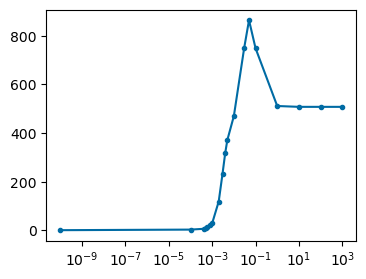

In [544]:
plt.plot(sigmas,kishe_sizes,'.-')
plt.xscale('log')
plt.show()

In [545]:
exp_error=exp_whole[selected_points,2]/scale_exp # normalize the residuals by exp. error

In [546]:
# find sigma that ~ minimizes overfitting (chi squared close to 1)
sigmas=np.array([5e-3,1e-2,2e-2,3e-2,3.5e-2,4e-2,5e-2])
for i in range(len(sigmas)):
    res_i = minimize(Gamma, np.zeros(qs.shape), method='BFGS',tol=1e-10,jac=True,
                   args=(colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp,sigmas[i]))
    w_me_i = weights_noprop(res_i.x,colv_rew[:,-1],spectra_ob[:,1:28],exp/scale_exp)
    kish_i = 1 / np.sum(w_me_i**2)
    # error (bootstrap) on the spectra: MAXENT weights
    nb=10 # N blocks, applies to both weights and spectra arrays
    npt=27 # N points per observable: saxs spectra have 51 q points in my case
    weights_me=copy.deepcopy(w_me_i[:-1]) # remove last to allow division by 10..
    weights_me=weights_me.reshape((nb,-1)) # weights
    spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
    spectra=spectra.reshape((nb,-1,npt))
    obs_j=[]
    for b in range(400):
        shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
        resamp_w=weights_me[shuffle][:,:].reshape((-1)) # resampled weights
        resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
        rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
        # 
        obs_j.append(rew_s)
    obs_j=np.array(obs_j)
    err_maxent_i=np.std(obs_j,axis=0)
    # print 
    print('sigma=%s, kish size=%s, chi squared=%s'%(
        sigmas[i],kish_i,1/(qs.shape[0]-1)*np.sum(((np.average(spectra_ob[:,1:28],axis=0,weights=w_me_i)-(exp/scale_exp))/np.sqrt(exp_error**2+err_maxent_i**2))**2)))

sigma=0.005, kish size=371.5692549459572, chi squared=0.18014416176873876
sigma=0.01, kish size=470.2645282609839, chi squared=0.23664661215005647
sigma=0.02, kish size=588.2312738951179, chi squared=0.39222036727013077
sigma=0.03, kish size=750.6754311348046, chi squared=0.8792863309343677
sigma=0.035, kish size=831.5692298925397, chi squared=1.197871221682001
sigma=0.04, kish size=887.2704458275981, chi squared=1.927750632377765
sigma=0.05, kish size=864.3329560344282, chi squared=4.389385673259109


In [547]:
chosen_s=3e-2
chosen_s

0.03

In [548]:
kishes[chosen_s]

np.float64(750.6754311348046)

In [549]:
kishes[chosen_s],spectra_ob.shape[0],kishes[chosen_s]/spectra_ob.shape[0]

(np.float64(750.6754311348046), 2001, np.float64(0.37515014049715373))

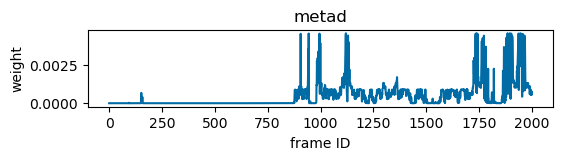

In [ ]:
plt.figure(figsize=(6,1))
plt.plot(weights)
plt.ylabel('weight')
plt.xlabel('frame ID')
plt.title('metad')
plt.show()
#plt.savefig(path_out+"/metad_weights_2000.png",dpi=300,bbox_inches="tight")

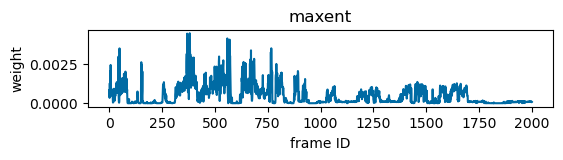

In [ ]:
plt.figure(figsize=(6,1))
plt.plot(w_me[chosen_s])
plt.ylabel('weight')
plt.xlabel('frame ID')
plt.title('maxent')
plt.show()
#plt.savefig(path_out+"/maxent_weights_2000.png",dpi=300,bbox_inches="tight")

In [552]:
np.sum(w_me[chosen_s])

np.float64(1.0)

#### Use the maxent weights for analyses

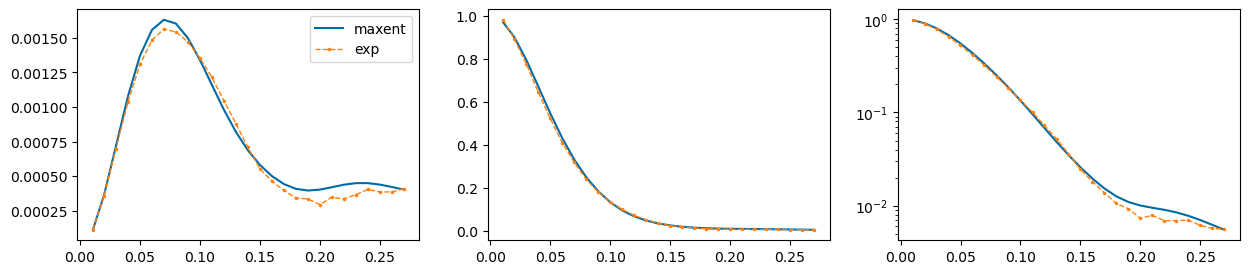

In [553]:
plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),label='maxent')
plt.plot(qs,exp/scale_exp*qs**2,'.--',lw=1,ms=3,label='exp')
plt.legend()

plt.subplot(1,3,2)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent')
plt.plot(qs,(exp/scale_exp),'.--',lw=1,ms=3,label='exp')

plt.subplot(1,3,3)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent')
plt.plot(qs,(exp/scale_exp),'.--',lw=1,ms=3,label='exp')
plt.yscale('log')
plt.show()

In [554]:
histo_me=np.histogram(colv_rew[:,5],bins=51,range=(2.0,3.3),weights=w_me[chosen_s])

<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2322869988.py:7: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Rg ($\AA$)')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2322869988.py:4: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='metad',c='C0',lw=2)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2322869988.py:5: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='maxent',c="C5",lw=2)


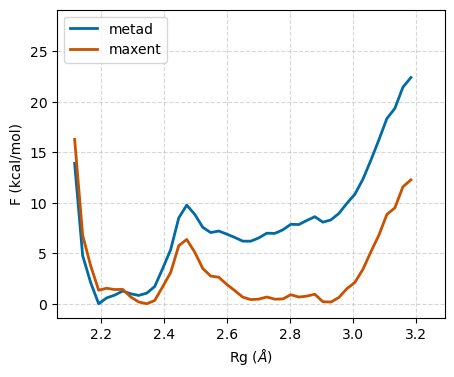

In [555]:
plt.figure(figsize=(5,4))
plt.style.use('tableau-colorblind10')
plt.grid(ls='--',alpha=0.5)
plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='metad',c='C0',lw=2)
plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='maxent',c="C5",lw=2)
plt.ylabel('F (kcal/mol)')
plt.xlabel('Rg ($\AA$)')
plt.legend()
plt.show()

In [556]:
# error (bootstrap) on the spectra: MAXENT weights
# error
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_me=copy.deepcopy(w_me[chosen_s][:-1]) # remove last to allow division by 10..
weights_me=weights_me.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_me[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    obs_j.append(rew_s)
obs_j=np.array(obs_j)
err_maxent=np.std(obs_j,axis=0)

In [557]:
# error (bootstrap) on the spectra: METAD weights
# error
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_metad=copy.deepcopy(weights[:-1]) # remove last to allow division by 10..
weights_metad=weights_metad.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_metad[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    obs_j.append(rew_s)
obs_j=np.array(obs_j)
err_metad=np.std(obs_j,axis=0)

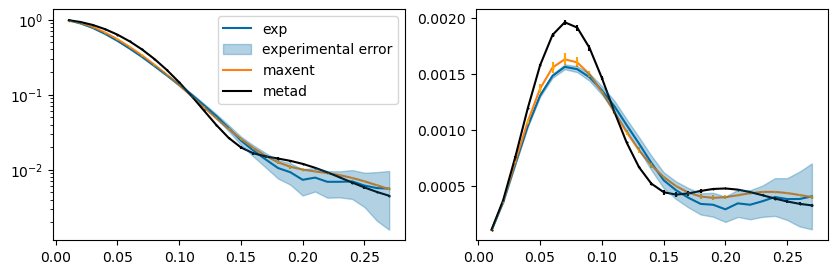

In [558]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(qs,(exp/scale_exp),label='exp')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp),
                 ((exp+exp_whole[selected_points,2])/scale_exp),
                 color='C0',label='experimental error',zorder=10,alpha=0.3)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent')
plt.errorbar(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),yerr=err_maxent,fmt='.',ms=1,color='orange')
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=weights),label='metad',color='black')
plt.errorbar(qs,np.average(spectra_ob[:,1:28],axis=0,weights=weights),yerr=err_metad,fmt='.',ms=1,color='black')
plt.legend()
plt.yscale('log')
plt.legend()

plt.subplot(1,2,2)
plt.plot(qs,(exp/scale_exp)*qs**2,label='exp')
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),label='maxent')
plt.errorbar(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),yerr=err_maxent*qs**2,fmt='.',ms=1,color='orange')
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=weights),label='metad',color='black')
plt.errorbar(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=weights),yerr=err_metad*qs**2,fmt='.',ms=1,color='black')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 ((exp+exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 color='C0',label='experimental error',zorder=10,alpha=0.3)


plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:25: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:25: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2497210388.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=14)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2497210388.py:6: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=14)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2497210388.py:25: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=14)


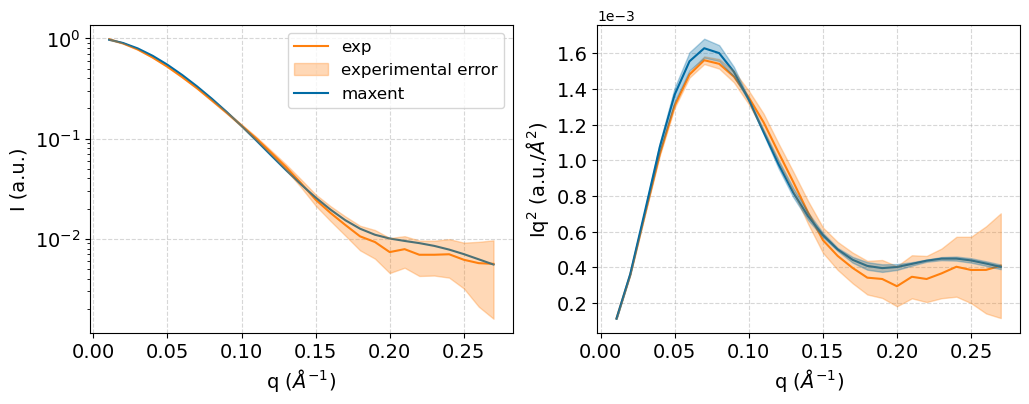

In [ ]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(12,4))
plt.subplot(1,2,2)
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.ylabel('Iq$^2$ (a.u./$\AA^2$)',fontsize=14)
plt.xlabel('q ($\AA^{-1}$)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(ls='--',alpha=0.5)
plt.plot(qs,(exp/scale_exp)*qs**2,label='exp',color='C1')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 ((exp+exp_whole[selected_points,2])/scale_exp)*exp_whole[selected_points,0]**2,
                 color='C1',label='experimental error',zorder=10,alpha=0.3)
plt.plot(qs,np.average(spectra_ob[:,1:28]*qs**2,axis=0,weights=w_me[chosen_s]),label='maxent',color='C0')
plt.fill_between(exp_whole[selected_points,0],
                 (np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])-err_maxent)*exp_whole[selected_points,0]**2,
                 (np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])+err_maxent)*exp_whole[selected_points,0]**2,
                 color='C0',label='maxent error',zorder=10,alpha=0.3)
#plt.legend()

plt.subplot(1,2,1)
plt.grid(ls='--',alpha=0.5)
plt.ylabel('I (a.u.)',fontsize=14)
plt.xlabel('q ($\AA^{-1}$)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.plot(qs,(exp/scale_exp),label='exp',color='C1')
plt.fill_between(exp_whole[selected_points,0],
                 ((exp-exp_whole[selected_points,2])/scale_exp),
                 ((exp+exp_whole[selected_points,2])/scale_exp),
                 color='C1',label='experimental error',zorder=10,alpha=0.3)
plt.plot(qs,np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]),label='maxent',color='C0')
plt.legend()
plt.yscale('log')
plt.legend(fontsize=12)
plt.show()
#plt.savefig(path_out+"/maxent_spectra_2000.png",dpi=300,bbox_inches="tight")

In [291]:
# chi squared, computed-exp: CONSISTENT WITH PRIMUS
1/(qs.shape[0]-1)*np.sum(((np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s])-(exp/scale_exp))/np.sqrt(exp_error**2+err_maxent**2))**2)

np.float64(0.849008988823938)

In [292]:
# error (bootstrap) on the spectra: MAXENT weights
# error on the residuals
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_me=copy.deepcopy(w_me[chosen_s][:-1]) # remove last to allow division by 10..
weights_me=weights_me.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_me[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    residuals_i=(((exp/scale_exp)-rew_s)/np.sqrt(exp_error**2+err_maxent**2)) # (((exp/scale_exp)-rew_s)/exp_error) 
    obs_j.append(residuals_i)
obs_j=np.array(obs_j)
err_maxent_residuals=np.std(obs_j,axis=0)

<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\A'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3912893503.py:10: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta$I/$\sigma$',fontsize=17)
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3912893503.py:11: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)',fontsize=17)


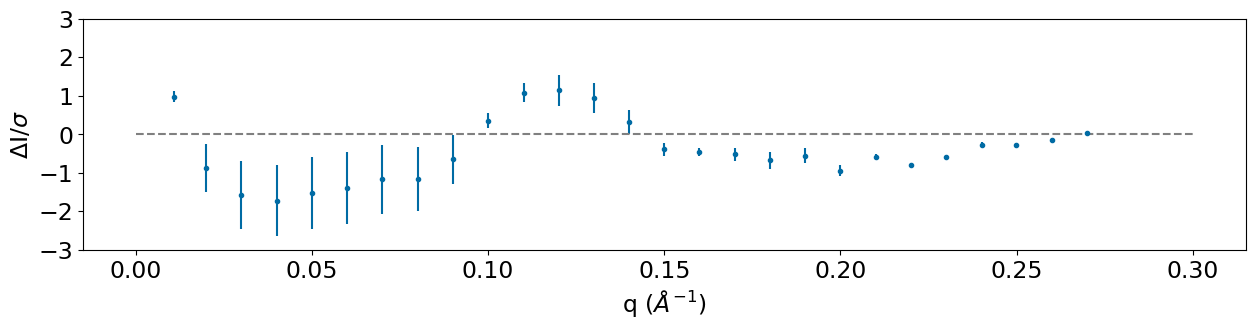

In [293]:
# CONSISTENT with primus + error (via bootstrap) on the calculated spectrum 
plt.figure(figsize=(15,3))
plt.style.use('tableau-colorblind10')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
exp_error=exp_whole[selected_points,2]/scale_exp # normalize the residuals by exp. error (!!DOUBLE CHECK ERROR PROPAGATION!!)
#plt.plot(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]))/np.sqrt(exp_error**2+err_maxent**2),'o')
plt.errorbar(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]))/np.sqrt(exp_error**2+err_maxent**2),yerr=err_maxent_residuals,fmt='.',label='rew. maxent')
plt.hlines(0,0,0.3,ls='--',color='grey')
plt.ylabel('$\Delta$I/$\sigma$',fontsize=17)
plt.xlabel('q ($\AA^{-1}$)',fontsize=17)
plt.ylim(-3,3)
plt.show()
#plt.savefig(path_out+'residuals.svg',dpi=300,bbox_inches='tight')

In [294]:
# error (bootstrap) on the spectra: METAD weights
# error on the residuals
nb=10 # N blocks, applies to both weights and spectra arrays
npt=27 # N points per observable: saxs spectra have 51 q points in my case
weights_metad=copy.deepcopy(weights[:-1]) # remove last to allow division by 10..
weights_metad=weights_metad.reshape((nb,-1)) # weights
spectra=copy.deepcopy(spectra_ob[:-1,1:28]) # spectra
spectra=spectra.reshape((nb,-1,npt))
obs_j=[]
for b in range(400):
    shuffle=np.random.choice(nb,size=nb) # re-sample by shuffling blocks
    resamp_w=weights_metad[shuffle][:,:].reshape((-1)) # resampled weights
    #
    resamp_s= spectra[shuffle][:,:,:].reshape((-1,npt)) # resampled spectra
    rew_s=(np.average(resamp_s,axis=0,weights=resamp_w/np.sum(resamp_w))) # reweighted spectrum
    # 
    residuals_i=(((exp/scale_exp)-rew_s)/np.sqrt(exp_error**2+err_metad**2)) # ((rew_s-(exp/scale_exp))/exp_error)
    obs_j.append(residuals_i)
obs_j=np.array(obs_j)
err_metad_residuals=np.std(obs_j,axis=0)

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3213149322.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('${\Delta}I/{\sigma}$')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/3213149322.py:8: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)')


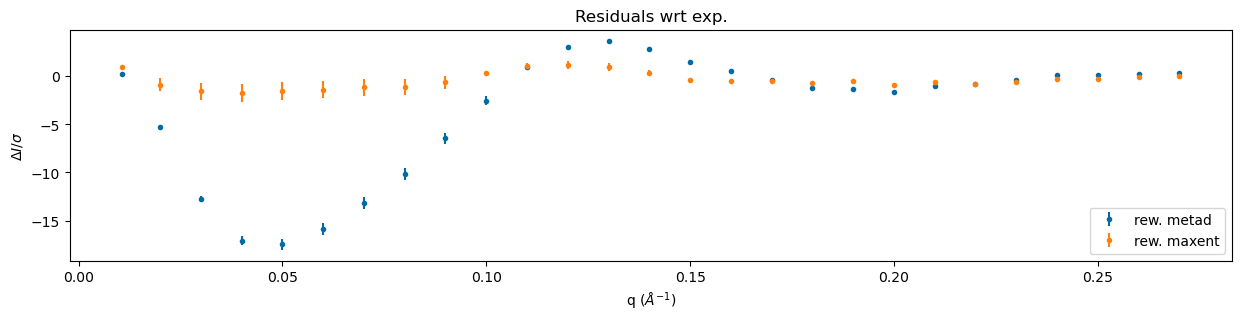

In [295]:
# normalized difference, with statistical error
exp_error=exp_whole[selected_points,2]/scale_exp
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(15,3))
plt.errorbar(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=weights))/np.sqrt(exp_error**2+err_metad**2),yerr=err_metad_residuals,fmt='.',label='rew. metad')
plt.errorbar(qs,((exp/scale_exp)-np.average(spectra_ob[:,1:28],axis=0,weights=w_me[chosen_s]))/np.sqrt(exp_error**2+err_maxent**2),yerr=err_maxent_residuals,fmt='.',label='rew. maxent')
plt.ylabel('${\Delta}I/{\sigma}$')
plt.xlabel('q ($\AA^{-1}$)')
plt.title('Residuals wrt exp.')
plt.legend()
plt.show()
#plt.savefig(path_out+'residuals_si.svg',dpi=300,bbox_inches='tight')

### Compute populations

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2311887037.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Rg ($\AA$)')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2311887037.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')
/var/folders/6x/hzxn2pps79lgs4k7n58p86fm0000gn/T/ipykernel_67689/2311887037.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='rew. maxent')


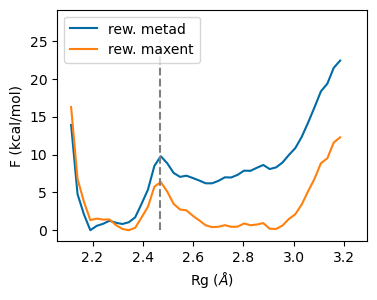

In [296]:
plt.plot((histo[1][:-1]+histo[1][1:])/2,(-2.5*np.log(histo[0])-np.min(-2.5*np.log(histo[0])))/4.184,label='rew. metad')
plt.plot((histo_me[1][:-1]+histo_me[1][1:])/2,(-2.5*np.log(histo_me[0])-np.min(-2.5*np.log(histo_me[0])))/4.184,label='rew. maxent')
plt.vlines(2.47,0,25,ls='--',color='grey')
plt.ylabel('F (kcal/mol)')
plt.xlabel('Rg ($\AA$)')
plt.legend()
plt.show()

In [297]:
# extended populations (Rg>2.47)
# maxent, metad
np.sum(w_me[chosen_s][np.where(colv_rew[:,5]>2.47)]),np.sum(weights[np.where(colv_rew[:,5]>2.47)])

(np.float64(0.6489497401105055), np.float64(6.294749018545153e-05))

In [298]:
# compact populations (Rg<2.47)
# maxent, metad
np.sum(w_me[chosen_s][np.where(colv_rew[:,5]<2.47)]),np.sum(weights[np.where(colv_rew[:,5]<2.47)])

(np.float64(0.35105025988949445), np.float64(0.9999370525098146))

## Contacts

In [300]:
#traj=mdt.load(path+'whole_cen_mol_protein_100ns_vb.xtc',top=path+'last_frame_replicate1_protein.pdb')
traj=mdt.load(path+'../../metad/output/whole_cen_mol_protein_100ns_vb.xtc',top=path+'last_frame_replicate1_protein.pdb',stride=10)
traj

<mdtraj.Trajectory with 2001 frames, 5829 atoms, 379 residues, and unitcells at 0x17ec44a70>

In [301]:
table, bonds = traj.top.to_dataframe()

In [302]:
chainA_idx=np.where(table['chainID'].to_numpy()==0)[0]

Nter: 24 to 84 counting from 1, thus 23 to 83 i.e. [23:84]  
Brc4: 340 to 378 i.e. [340:379]

In [303]:
ctcs=mdt.compute_contacts(traj,contacts=[[23, 339], [0, 378]],scheme='closest-heavy')

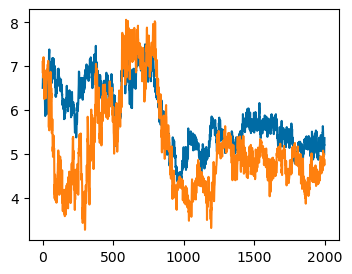

In [304]:
plt.plot(ctcs[0][:,0])
plt.plot(ctcs[0][:,1])

In [305]:
brc4_grp=np.array(list(itertools.product(np.arange(340,379,1),np.arange(23,84,1))))
brc4_grp.shape

(2379, 2)

In [306]:
brc4_grp_allN=np.array(list(itertools.product(np.arange(340,379,1),np.arange(0,84,1))))
brc4_grp_allN.shape

(3276, 2)

In [307]:
brc4_ctc=mdt.compute_contacts(traj,contacts=brc4_grp,scheme='closest-heavy')

In [309]:
start=datetime.datetime.now()

brc4_ctc_allN=mdt.compute_contacts(traj,contacts=brc4_grp_allN,scheme='closest-heavy')

end=datetime.datetime.now()
tdelta=end-start
print("total seconds:",tdelta.total_seconds())

total seconds: 12.829527


In [310]:
np.unique(brc4_ctc[1][:,0]).shape,np.unique(brc4_ctc[1][:,1]).shape

((39,), (61,))

In [311]:
brc4_ctc_filt=1*(brc4_ctc[0]<0.5)

In [312]:
brc4_ctc_allN_filt=1*(brc4_ctc_allN[0]<0.5)

In [313]:
brc4_ctc_filt_resh=brc4_ctc_filt.reshape(brc4_ctc_filt.shape[0],-1,61)

In [314]:
brc4_ctc_allN_filt_resh=brc4_ctc_allN_filt.reshape(brc4_ctc_allN_filt.shape[0],-1,84)

In [315]:
nter_grp=np.array(list(itertools.product(np.arange(23,84,1),np.arange(340,379,1))))

In [316]:
nter_grp_allN=np.array(list(itertools.product(np.arange(0,84,1),np.arange(340,379,1))))

In [317]:
start=datetime.datetime.now()

nter_ctc=mdt.compute_contacts(traj,contacts=nter_grp,scheme='closest-heavy')

end=datetime.datetime.now()
tdelta=end-start
print("total seconds:",tdelta.total_seconds())

total seconds: 9.178359


In [318]:
nter_ctc_filt=1*(nter_ctc[0]<0.5)

In [319]:
nter_ctc_filt_resh=nter_ctc_filt.reshape(nter_ctc_filt.shape[0],-1,39)

In [320]:
chainA_idx=np.where(table['chainID'].to_numpy()==0)[0]
chainB_idx=np.where(table['chainID'].to_numpy()==1)[0]

In [321]:
# residue.index counts from 0, residue.resSeq counts as the pdb (e.g. from 1), compute_contacts considers residues 0-indexed
nter_residues=[a.residue for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(24,84,61,dtype=int)] # resids 24 to 84
brc4_residues=[a.residue for a in traj.top.atoms if a.index in chainB_idx if a.name=='CA' if a.residue.resSeq in np.linspace(1,39,40,dtype=int)] 

In [322]:
# residue.index counts from 0, residue.resSeq counts as the pdb (e.g. from 1), compute_contacts considers residues 0-indexed
nter_allN_residues=[a.residue for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(0,84,85,dtype=int)]
cter_allN_residues=[a.residue for a in traj.top.atoms if a.index in chainA_idx if a.name=='CA' if a.residue.resSeq in np.linspace(84,340,256,dtype=int)]

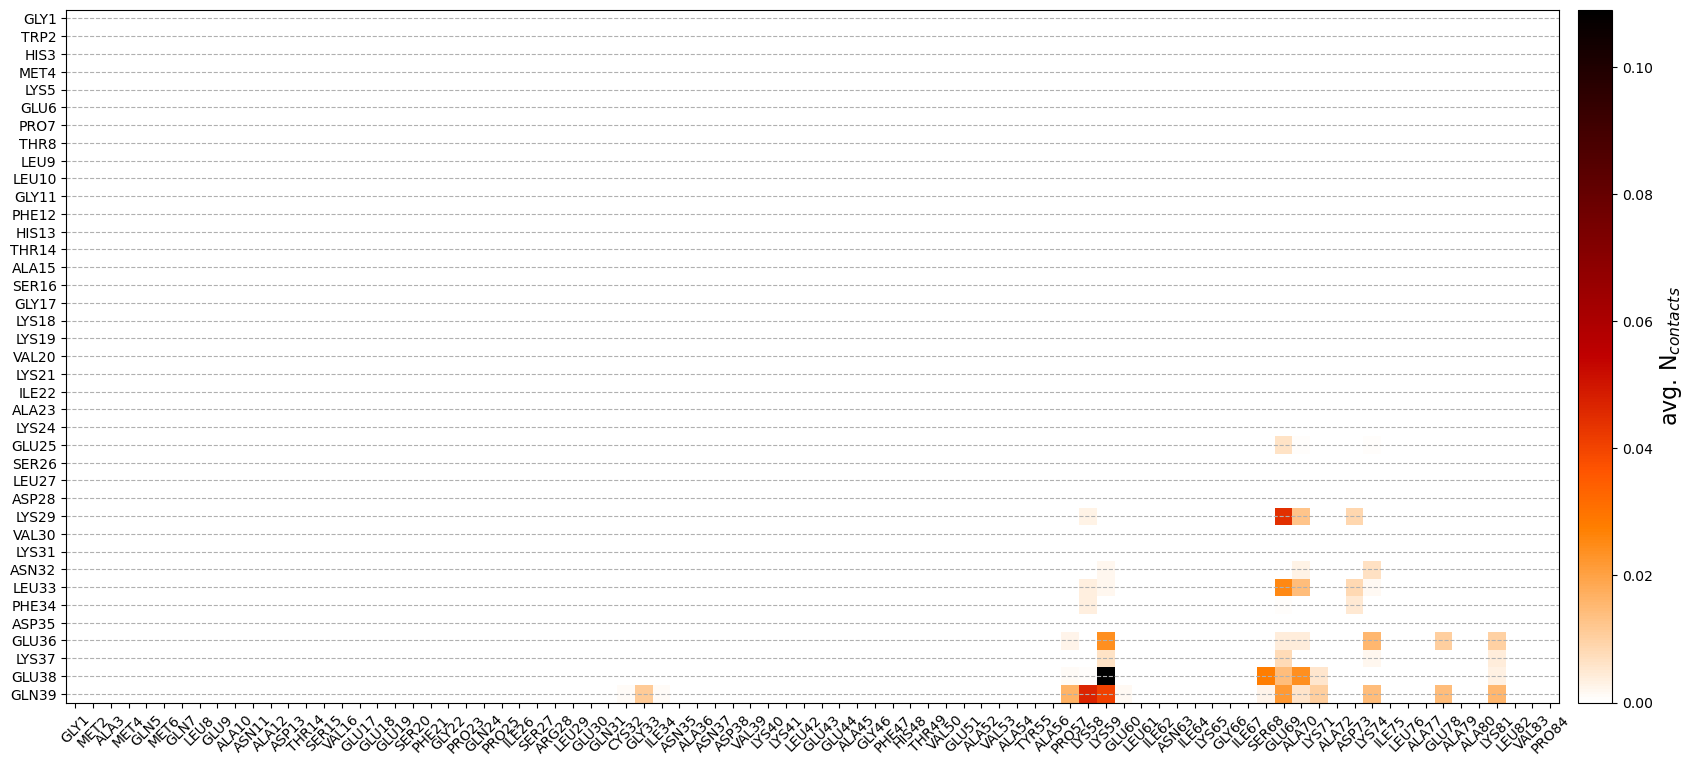

In [323]:
from matplotlib import colormaps
plt.figure(figsize=(24,9))
cmap = colormaps['gist_heat_r']
plt.imshow(np.average(brc4_ctc_allN_filt_resh,axis=0,weights=w_me[chosen_s]),cmap)
plt.colorbar(orientation="vertical",pad=0.01).ax.set_ylabel('avg. N$_{contacts}$', fontsize=16)
plt.yticks(np.linspace(0,38,39),brc4_residues)
plt.xticks(np.linspace(0,83,84),nter_allN_residues,rotation=45)
plt.grid(axis='y',ls='--')
plt.show()
#plt.savefig(path_out+'contacts_matrix_new_heat.png',dpi=300,bbox_inches='tight')

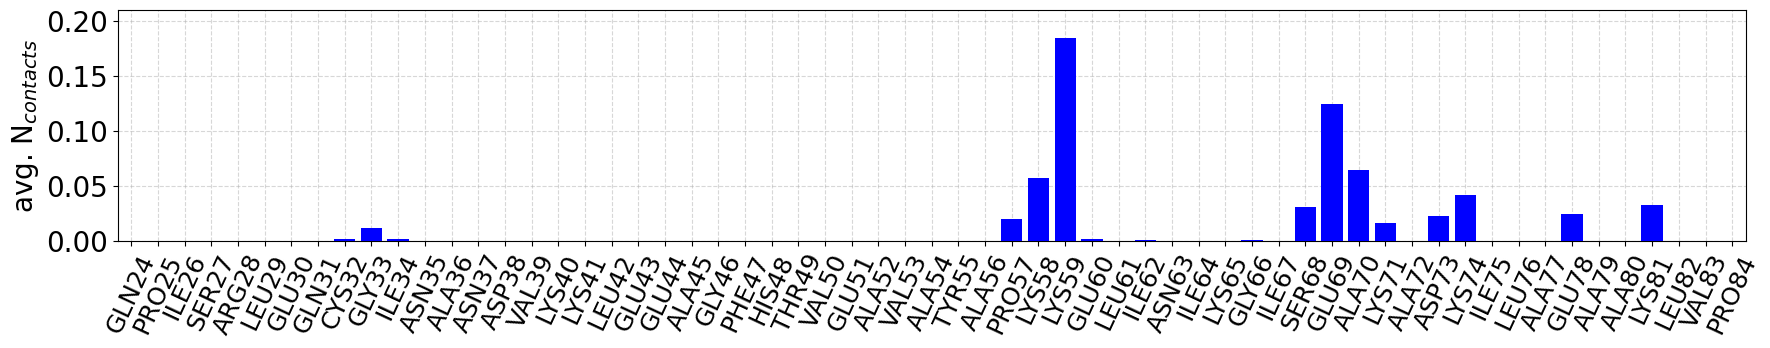

In [324]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(21,3))
plt.bar(np.linspace(0,60,61),np.average(np.sum(nter_ctc_filt_resh,axis=2),axis=0,weights=w_me[chosen_s]),width=0.8,zorder=10,color='blue')
plt.xticks(np.linspace(0,60,61),nter_residues,rotation=65,fontsize=18)
plt.xlim(-0.5,60.5)
plt.ylim(0,0.21)
plt.ylabel('avg. N$_{contacts}$',fontsize=20)
plt.yticks(fontsize=20)
plt.grid(ls='--',alpha=0.5)
#plt.savefig(path_out+'contacts_nter.svg',dpi=300,bbox_inches='tight')
plt.show()

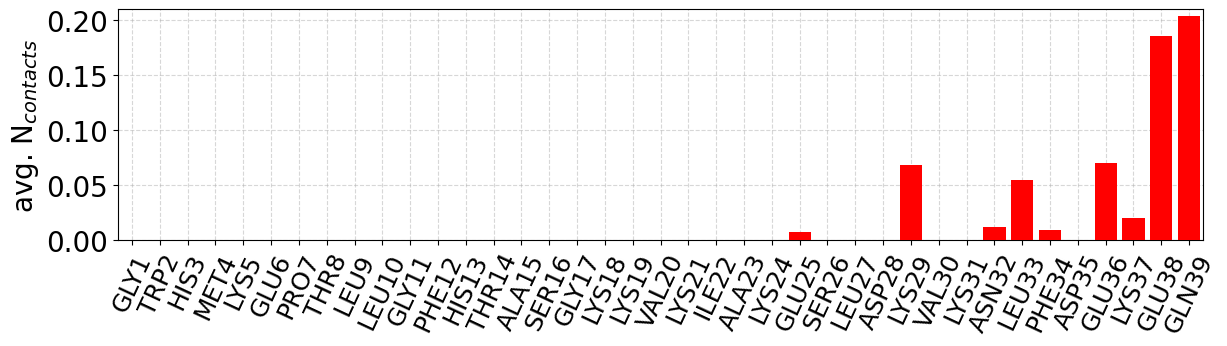

In [325]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(14,3))
plt.bar(np.linspace(0,38,39),np.average(np.sum(brc4_ctc_filt_resh,axis=2),axis=0,weights=w_me[chosen_s]),width=0.8,zorder=10,color='red')
plt.xticks(np.linspace(0,38,39),brc4_residues,rotation=65,fontsize=18)
plt.yticks(fontsize=20)
plt.xlim(-0.5,38.5)
plt.ylim(0,0.21)
plt.ylabel('avg. N$_{contacts}$',fontsize=20)
plt.grid(ls='--',alpha=0.5)
plt.show()
#plt.savefig(path_out+'contacts_brc4.svg',dpi=300,bbox_inches='tight')
plt.show()